In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#read json file

with open('bad_nauheim_data.json','r') as file:
    content = json.load(file)


In [3]:
#Convert json file into data frame

df = pd.DataFrame.from_dict(content['sensordata'])


In [4]:
# View dataFrame
df

,visitors,geoJson,locationId,name,location,lon,lat,avgDuration,timestamp,SID,_headers
0,7,None,415,Karlstraße 15,city_bad_nauh,8.739320,50.36408,16.02,2025-06-30T01:00:00.000Z,d5261325-e40c-4ed4-bbbf-5ce24d3de844,{'eventType': 'AriadneAreaEventType'}
1,1,None,415,Trafohaus Zanderstraße,city_bad_nauh,8.742841,50.36250,28.22,2025-06-30T01:00:00.000Z,dc716491-cffe-4661-bbe4-333b581a6926,{'eventType': 'AriadneAreaEventType'}
2,4,None,415,Friedrichstraße 11,city_bad_nauh,8.735750,50.36414,6.61,2025-06-30T01:00:00.000Z,cca912bc-7296-42fe-a37c-6f19b2840556,{'eventType': 'AriadneAreaEventType'}
3,2,None,415,Parkstraße 24,city_bad_nauh,8.736540,50.36557,7.78,2025-06-30T01:00:00.000Z,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,{'eventType': 'AriadneAreaEventType'}
4,9,None,415,Hauptstraße 36,city_bad_nauh,8.737240,50.36368,19.97,2025-06-30T01:00:00.000Z,b8419dcf-9ac6-4dab-9a7b-8af4718b74e1,{'eventType': 'AriadneAreaEventType'}
...,...,...,...,...,...,...,...,...,...,...,...
17573,4,None,415,Hauptstraße 8,city_bad_nauh,8.739170,50.36376,15.63,2025-07-13T23:00:00.000Z,481da5b9-afd5-44c5-b29b-6c3e23a59bcb,{'eventType': 'AriadneAreaEventType'}
17574,14,None,415,Reinhardstraße 19,city_bad_nauh,8.736910,50.36416,37.67,2025-07-13T23:00:00.000Z,7d06c31f-aa88-4c5b-8280-565243350ad8,{'eventType': 'AriadneAreaEventType'}
17575,34,None,415,Innenstadt,city_bad_nauh,NaN,NaN,42.92,2025-07-13T23:00:00.000Z,3cc1e766-97c5-4ed0-92c3-a800b5be8658,{'eventType': 'AriadneAreaEventType'}
17576,10,None,415,Karlstraße 15,city_bad_nauh,8.739320,50.36408,35.25,2025-07-13T23:00:00.000Z,d5261325-e40c-4ed4-bbbf-5ce24d3de844,{'eventType': 'AriadneAreaEventType'}


In [5]:
#Explore data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17578 entries, 0 to 17577
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   visitors     17578 non-null  int64  
 1   geoJson      0 non-null      object 
 2   locationId   17578 non-null  int64  
 3   name         17578 non-null  str    
 4   location     17578 non-null  str    
 5   lon          16081 non-null  float64
 6   lat          16081 non-null  float64
 7   avgDuration  17578 non-null  float64
 8   timestamp    17578 non-null  str    
 9   SID          17578 non-null  str    
 10  _headers     17578 non-null  object 
dtypes: float64(3), int64(2), object(2), str(4)
memory usage: 3.0+ MB


In [6]:
# Numerical datas that are important to us
df[['visitors','avgDuration']].describe()

,visitors,avgDuration
count,17578.000000,17578.000000
mean,54.756798,10.261508
std,80.323996,7.108359
min,0.000000,0.000000
25%,12.000000,6.192500
50%,32.000000,8.920000
75%,65.000000,12.640000
max,1007.000000,104.730000


In [7]:
#Find out the columns in data frame
df.columns

Index(['visitors', 'geoJson', 'locationId', 'name', 'location', 'lon', 'lat',
       'avgDuration', 'timestamp', 'SID', '_headers'],
      dtype='str')

In [8]:
#Extract only the columns that are required from the dataset
columns = ['visitors','name','avgDuration','timestamp','SID']

df = df[columns]
print(df.head(n=10))

   visitors                    name  avgDuration                 timestamp  \
0         7           Karlstraße 15        16.02  2025-06-30T01:00:00.000Z   
1         1  Trafohaus Zanderstraße        28.22  2025-06-30T01:00:00.000Z   
2         4      Friedrichstraße 11         6.61  2025-06-30T01:00:00.000Z   
3         2           Parkstraße 24         7.78  2025-06-30T01:00:00.000Z   
4         9          Hauptstraße 36        19.97  2025-06-30T01:00:00.000Z   
5         3            Parkstraße 4         3.14  2025-06-30T01:00:00.000Z   
6         3           Alicestraße 2        11.18  2025-06-30T01:00:00.000Z   
7        23              Innenstadt        28.46  2025-06-30T01:00:00.000Z   
8        21              Innenstadt        14.10  2025-06-30T01:00:00.000Z   
9         4           Schulstraße 6         7.11  2025-06-30T01:00:00.000Z   

                                    SID  
0  d5261325-e40c-4ed4-bbbf-5ce24d3de844  
1  dc716491-cffe-4661-bbe4-333b581a6926  
2  cca912bc-729

In [9]:
#Check for NaN values
df.isna().sum()

visitors       0
name           0
avgDuration    0
timestamp      0
SID            0
dtype: int64

In [10]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [11]:
df['weekday'] = df['timestamp'].dt.day_of_week

In [12]:
df['time'] = df['timestamp'].dt.hour

In [13]:
# To treat 23 and 0 are neighbours
df['hour_sin'] = np.sin(2 * np.pi * df['time'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['time'] / 24)

In [14]:
#Drop time
df = df.drop(['time'],axis = 1)

In [15]:
df.columns

Index(['visitors', 'name', 'avgDuration', 'timestamp', 'SID', 'weekday',
       'hour_sin', 'hour_cos'],
      dtype='str')

In [16]:
#Export to csv for analysis
df.to_csv('bad_nauheim.csv')


In [17]:
#After analysis we found that for a same timestamp, there exists a different readings for same sensor and place

df = df.groupby(['name','SID','timestamp']).agg(
    {'visitors': 'mean',
    'avgDuration': 'mean',
    'weekday': 'first',
    'hour_sin': 'first',
    'hour_cos': 'first'}).reset_index().sort_values(by=['SID','name','timestamp'])

In [18]:
df

,name,SID,timestamp,visitors,avgDuration,weekday,hour_sin,hour_cos
2543,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 01:00:00+00:00,1.00,17.5500,0,0.258819,0.965926
2544,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 02:00:00+00:00,3.00,4.1000,0,0.500000,0.866025
2545,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 03:00:00+00:00,3.00,0.7500,0,0.707107,0.707107
2546,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 04:00:00+00:00,16.75,6.2075,0,0.866025,0.500000
2547,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 05:00:00+00:00,27.50,5.1475,0,0.965926,0.258819
...,...,...,...,...,...,...,...,...
4905,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 02:00:00+00:00,6.00,12.6400,6,0.500000,0.866025
4906,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 03:00:00+00:00,3.50,10.8700,6,0.707107,0.707107
4907,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 04:00:00+00:00,10.00,8.2600,6,0.866025,0.500000
4908,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 21:00:00+00:00,0.50,6.7900,6,-0.707107,0.707107


In [19]:
#Find out the number of sensors
df['SID'].nunique()

30

In [20]:
#Determine the sensors with most readings
df['SID'].value_counts().head(n=10)

SID
cca912bc-7296-42fe-a37c-6f19b2840556    256
b8419dcf-9ac6-4dab-9a7b-8af4718b74e1    252
d5261325-e40c-4ed4-bbbf-5ce24d3de844    252
481da5b9-afd5-44c5-b29b-6c3e23a59bcb    251
3cc1e766-97c5-4ed0-92c3-a800b5be8658    250
bc5edd25-415e-40fb-8607-ad8c0b10ea4c    250
ee12f4cf-9fbe-4c2a-b3fb-7783a3d78355    250
4ff66154-8c30-4f61-9e54-d5c1744c117c    249
db726d5d-f282-4977-ad4f-400853262062    249
d52b73da-cc5a-4e5d-83dd-3c028d3435ca    248
Name: count, dtype: int64

In [21]:
#Sensors comparison

df.groupby(['SID','name'])['visitors'].mean().sort_values(ascending= False)

SID                                   name                             
3cc1e766-97c5-4ed0-92c3-a800b5be8658  Innenstadt                           262.496800
bc5edd25-415e-40fb-8607-ad8c0b10ea4c  Kurpark                              110.125667
ee12f4cf-9fbe-4c2a-b3fb-7783a3d78355  Kurstraße 7                           83.394867
db726d5d-f282-4977-ad4f-400853262062  Reinhardstraße 2                      63.863387
d5261325-e40c-4ed4-bbbf-5ce24d3de844  Karlstraße 15                         59.018254
d52b73da-cc5a-4e5d-83dd-3c028d3435ca  Alicestraße 2                         49.321237
dd520fc1-e6de-4f55-b6d8-508373be5330  Kurpark - Eingang Kolonnaden          49.247270
b0d968cd-ded3-4953-b99f-2cb5fabd086d  Kurpark - Eingang Sprudelhof          48.064224
e43beee4-de88-43f8-9c31-c3f0d5dc1451  Kurstraße 13                          39.712602
bb71e93c-fc02-464c-acf0-f2c6c453762d  Stresemannstraße 6                    38.994593
4ff66154-8c30-4f61-9e54-d5c1744c117c  Karlstraße 6                  

In [22]:
# BoxPlot Analysis for each sensors for detecting possible outliers

sensors = df['SID'].value_counts().head(n=30).index

def boxplot_analysis_visitors(sensor):
    data = df[df['SID'] == sensor]
    plt.clf()
    plt.boxplot(data['visitors'])
    name = data['name'].iloc[0] 
    plt.title(f'Box Plot for Visitors -location {name}')
    plt.xlabel(f'Sensor: {sensor}')
    plt.xticks([])
    plt.tight_layout()
    plt.show()

In [23]:
def boxplot_analysis_averageDuration(sensor):
    data = df[df['SID'] == sensor]
    plt.clf()
    plt.boxplot(data['avgDuration'])
    name = data['name'].iloc[0] 
    plt.title(f'Box plot for avgDuration - location {name}')
    plt.xlabel(f'Sensor: {sensor}')
    plt.xticks([])
    plt.tight_layout()
    plt.show()

In [24]:
def vistors_data_distribution(sensor):
    data = df[df['SID'] == sensor]
    plt.clf()
    plt.hist(data['visitors'],bins=5)
    plt.xlabel("visitors")
    plt.ylabel("count")
    name = data['name'].iloc[0] 
    plt.title(f'visitors distribution for Sensor {sensor} at location {name}')
    plt.tight_layout()
    plt.show()

In [25]:
def avgDuration_data_distribution(sensor):
    data = df[df['SID'] == sensor]
    plt.clf()
    plt.hist(data['avgDuration'],bins=5)
    plt.xlabel("avgDuration")
    plt.ylabel("count")
    name = data['name'].iloc[0] 
    plt.title(f'visitors distribution for Sensor {sensor} at location {name}')
    plt.tight_layout()
    plt.show()
    

In [26]:
#Visitor Pattern analysis for each sensor

def pattern_analysis(sensor):
    data = df[df['SID'] == sensor]
    plt.clf()
    plt.plot(data['visitors'])
    name = data['name'].iloc[0] 
    plt.title(f'visitors pattern at location {name}')
    plt.xlabel(f'sensor: {sensor}')
    plt.xticks([])
    plt.tight_layout()
    plt.show()
    

In [27]:
#average Duration Pattern analysis for each sensor

def avgDuration_pattern_analysis(sensor):
    data = df[df['SID'] == sensor]
    plt.clf()
    plt.plot(data['avgDuration'])
    name = data['name'].iloc[0] 
    plt.title(f'avgDuration pattern at location {name}')
    plt.xlabel(f'sensor: {sensor}')
    plt.xticks([])
    plt.tight_layout()
    plt.show()

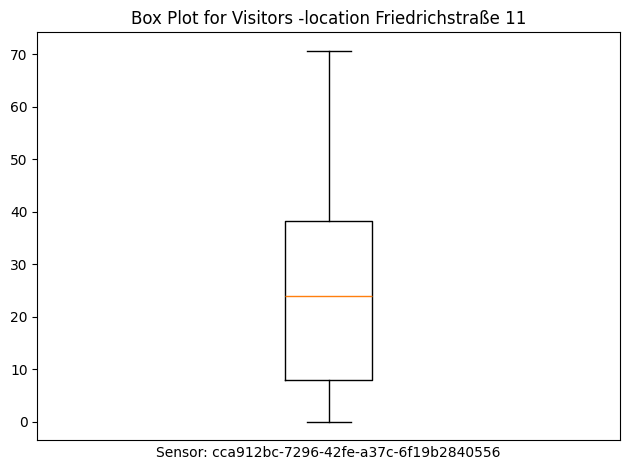

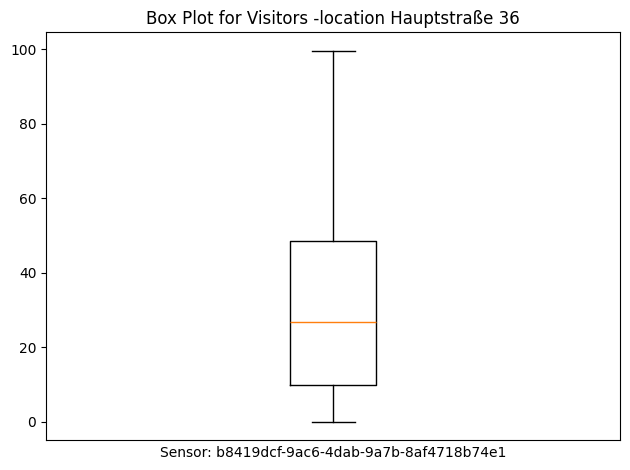

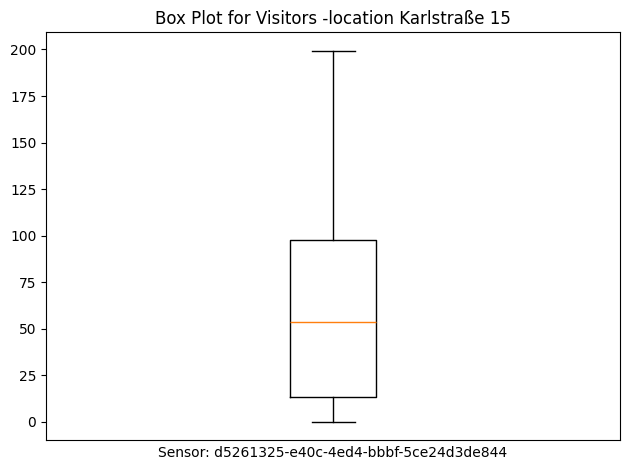

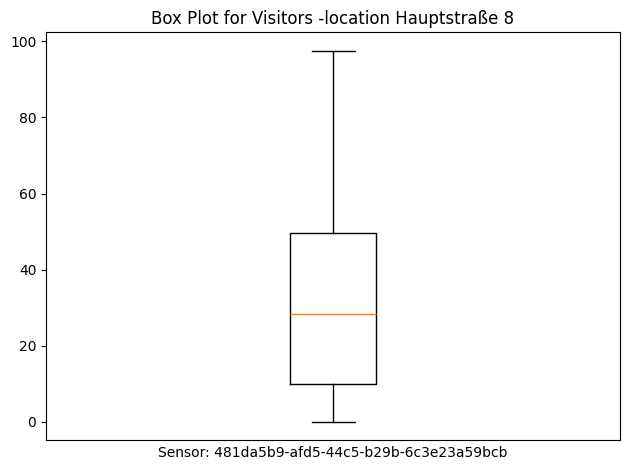

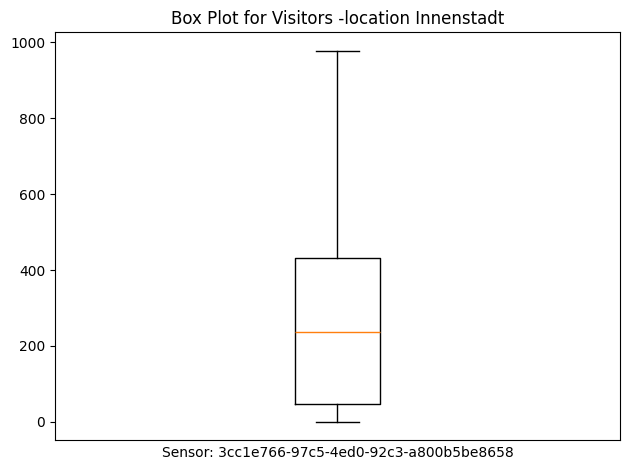

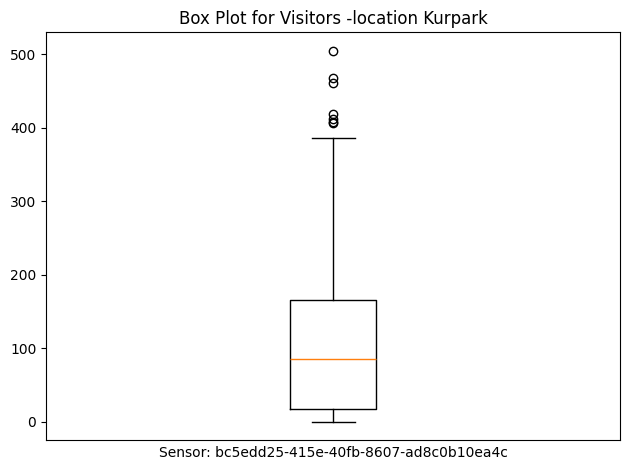

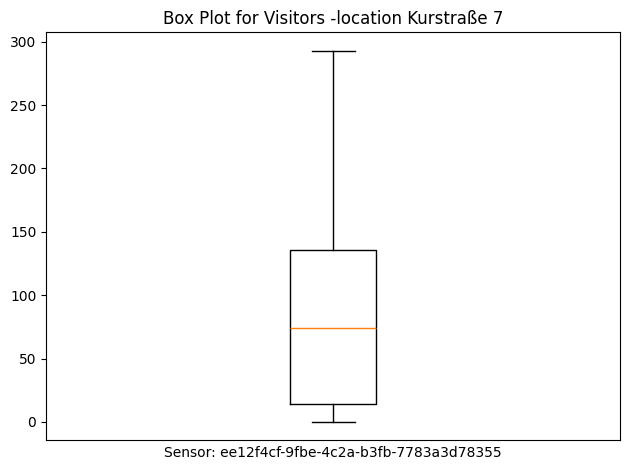

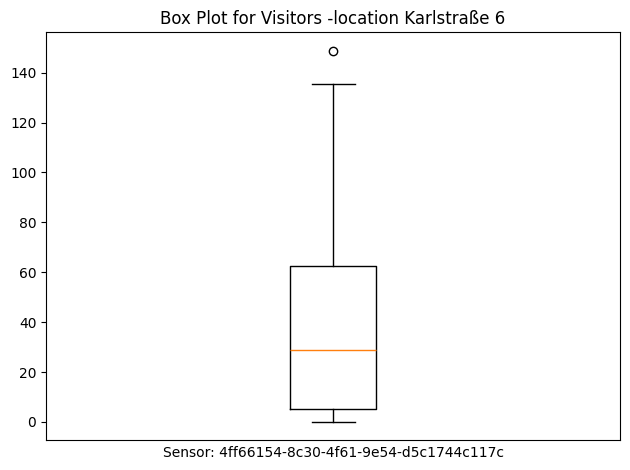

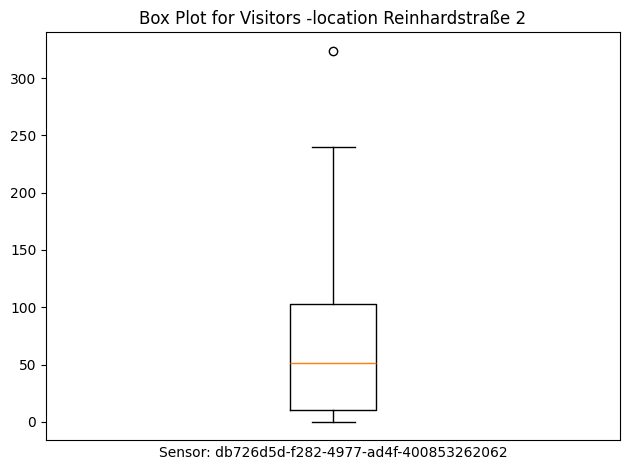

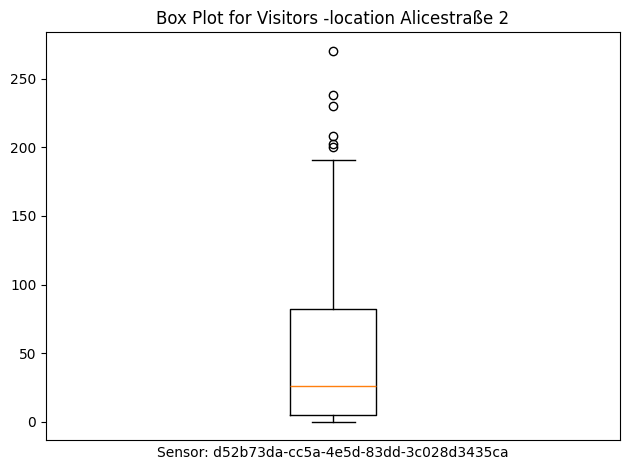

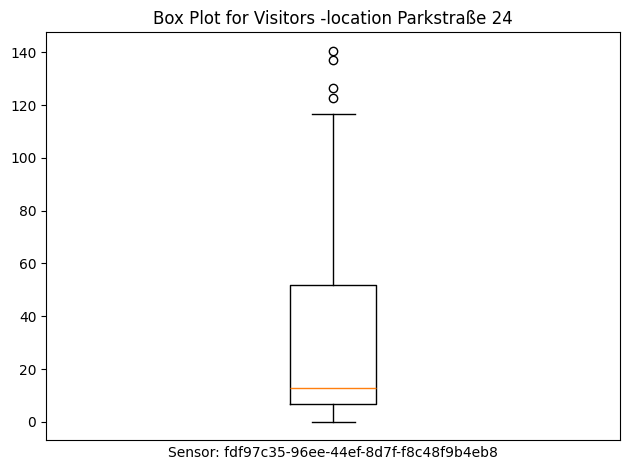

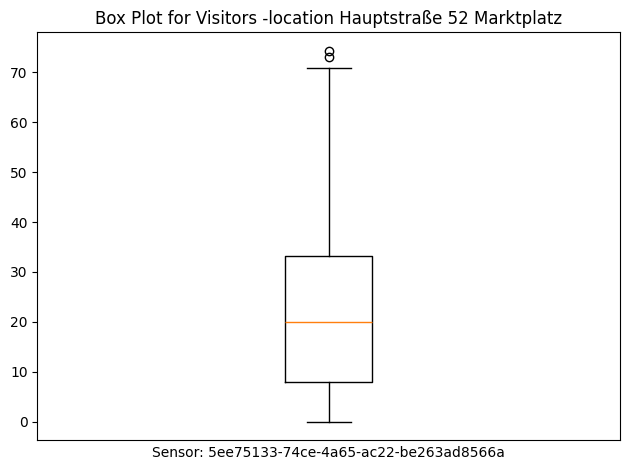

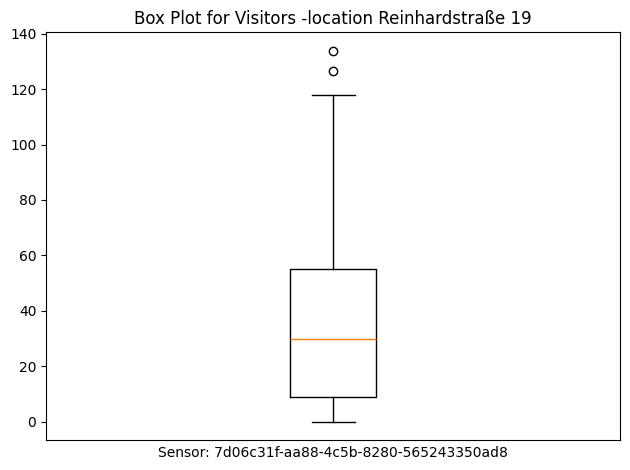

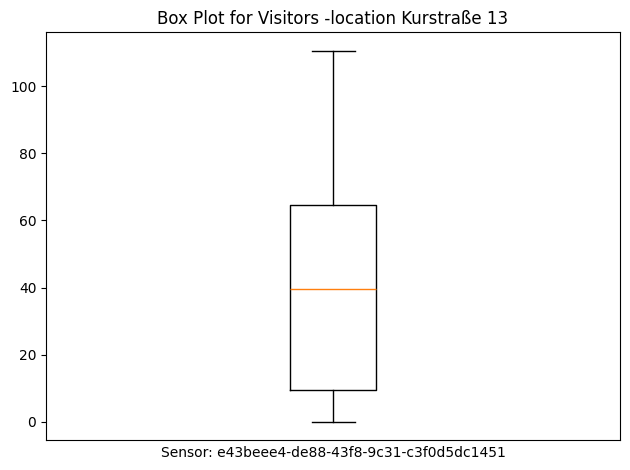

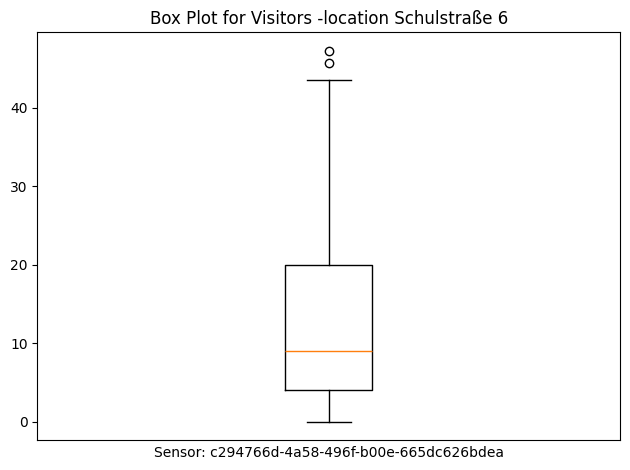

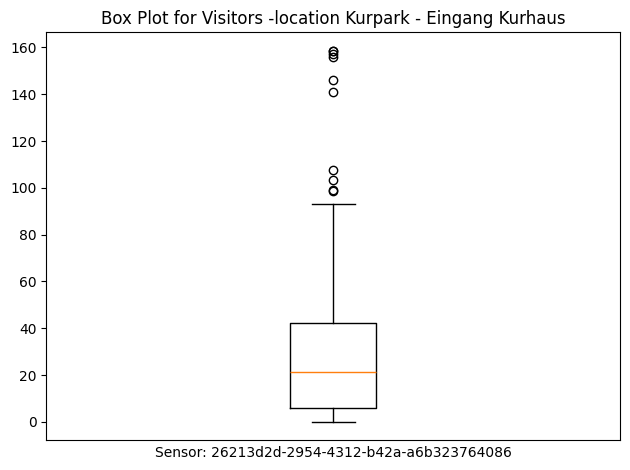

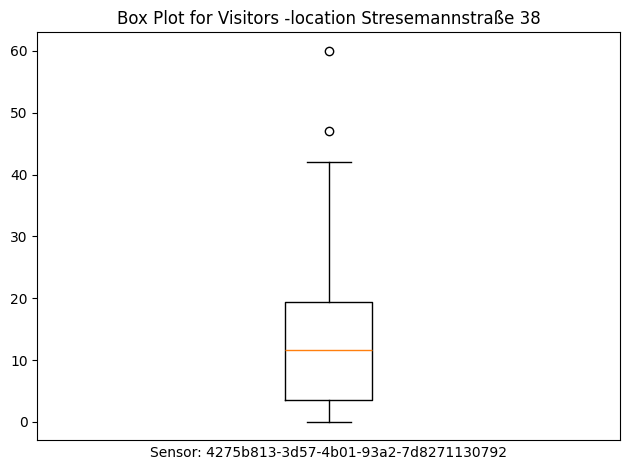

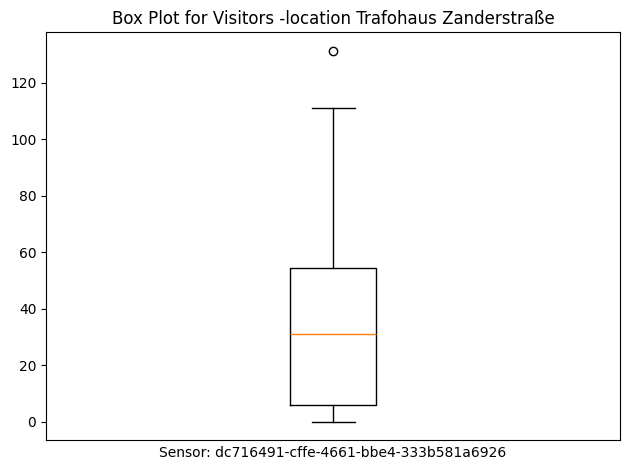

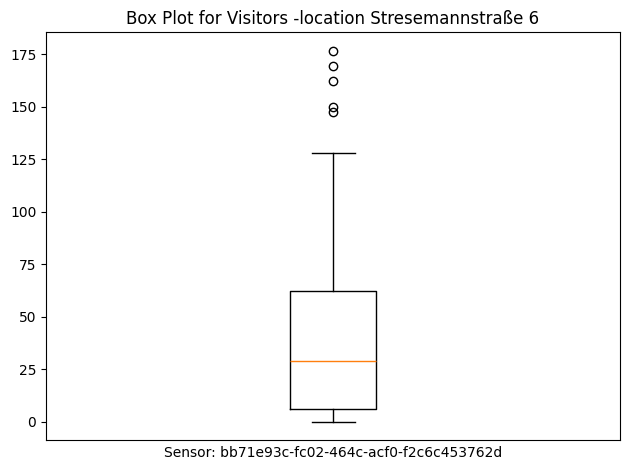

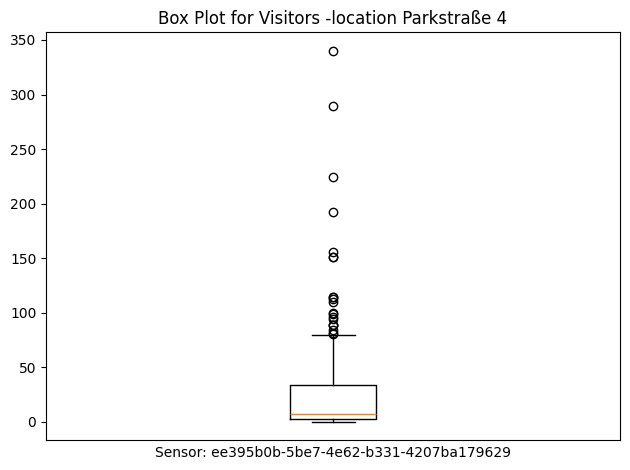

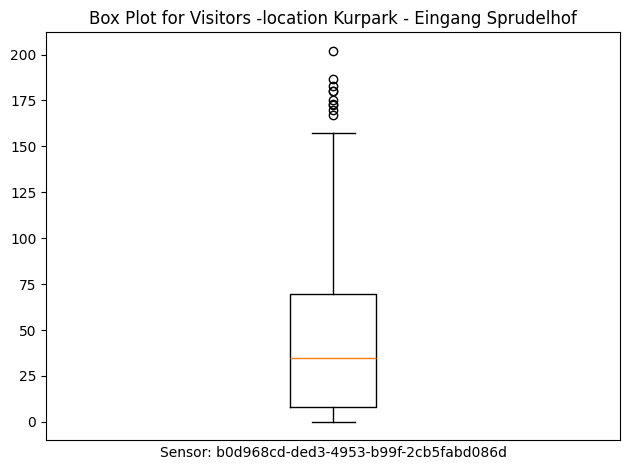

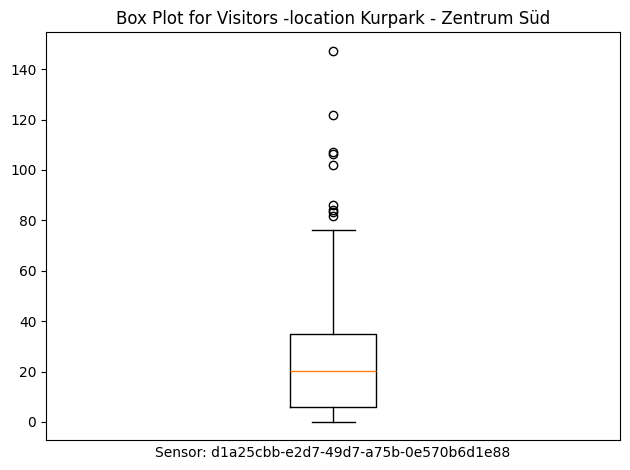

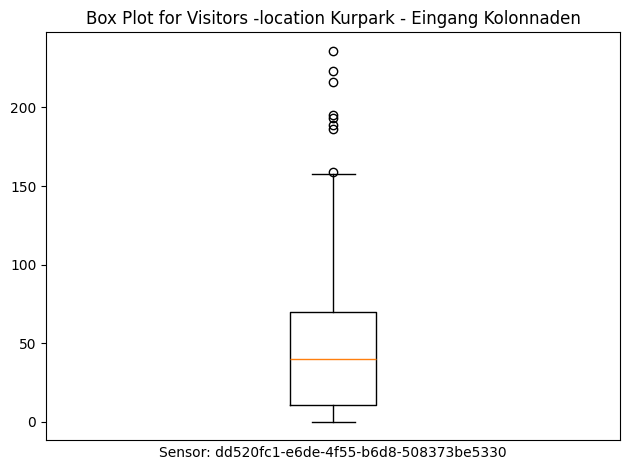

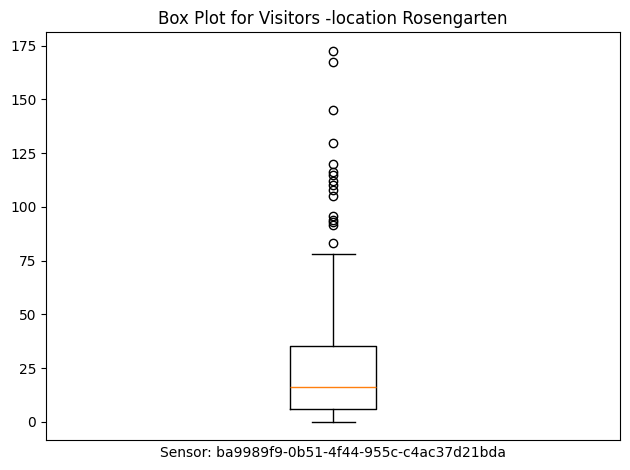

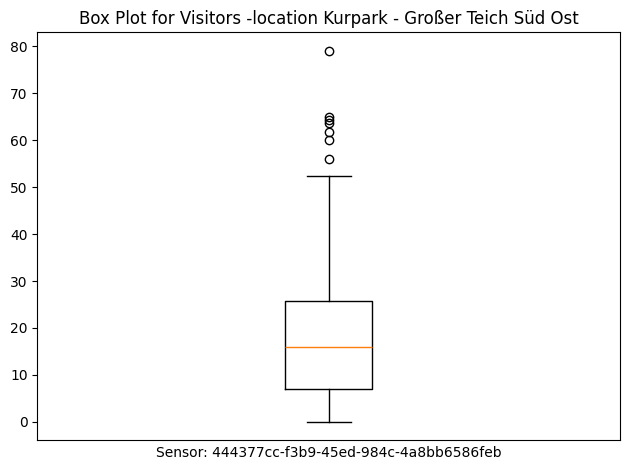

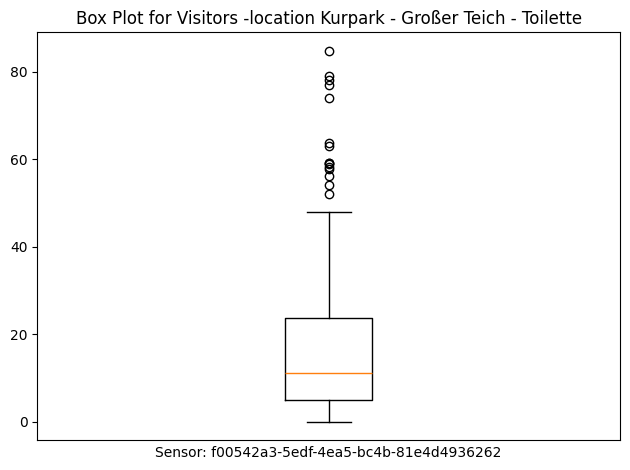

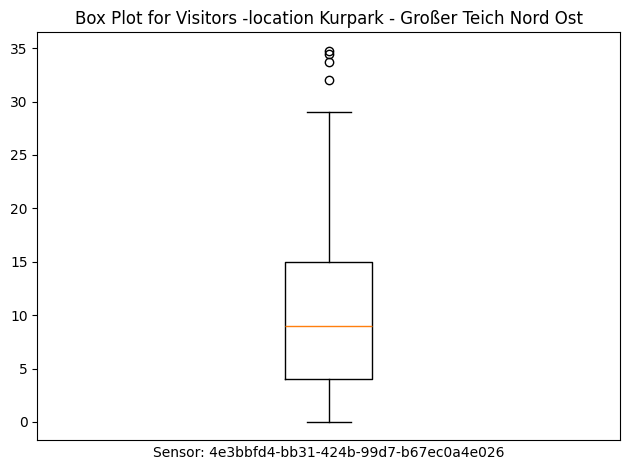

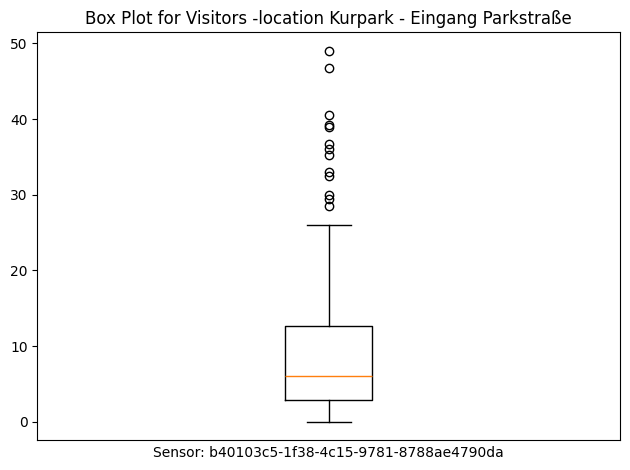

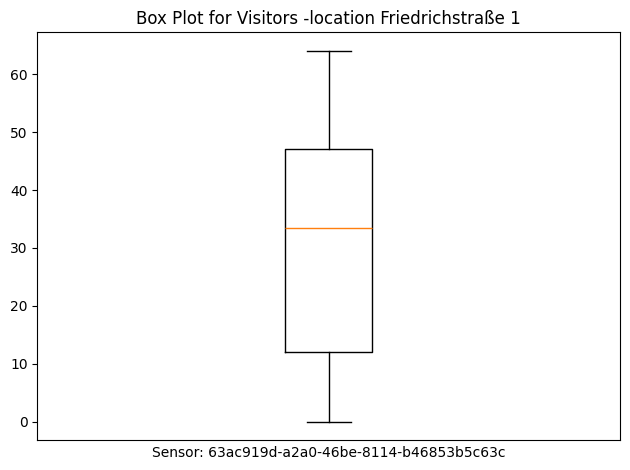

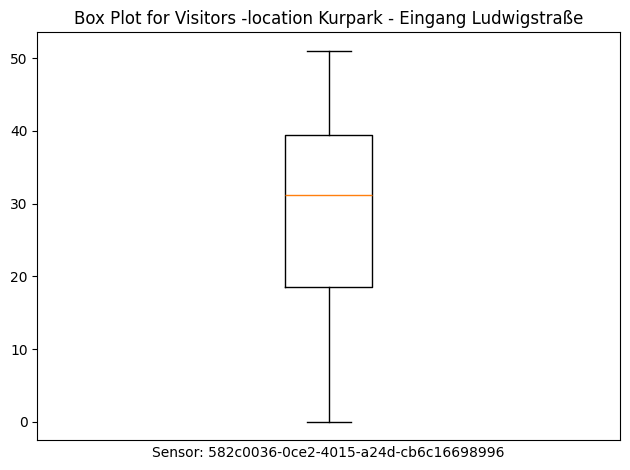

In [28]:
for sensor in sensors:
    boxplot_analysis_visitors(sensor)

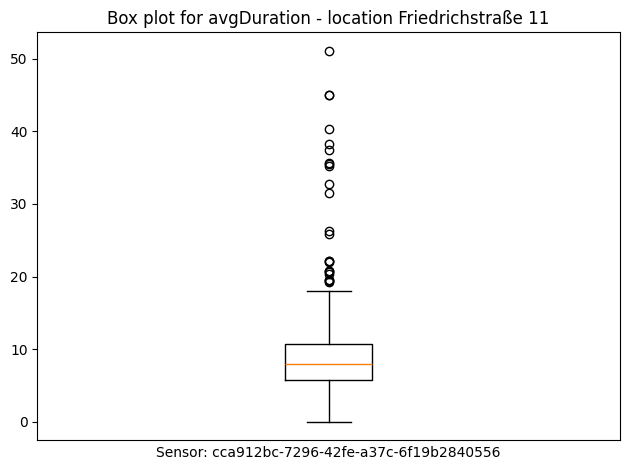

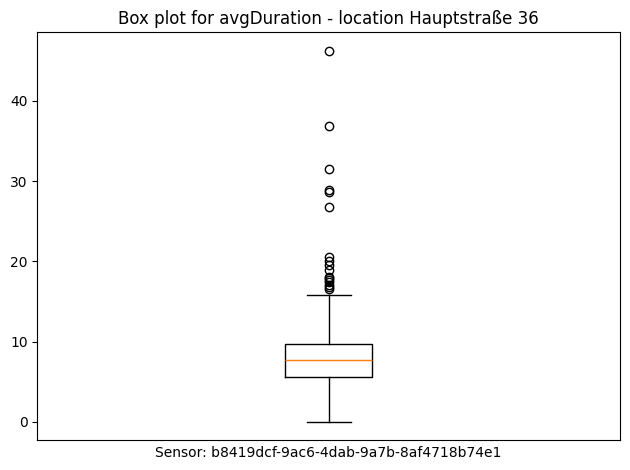

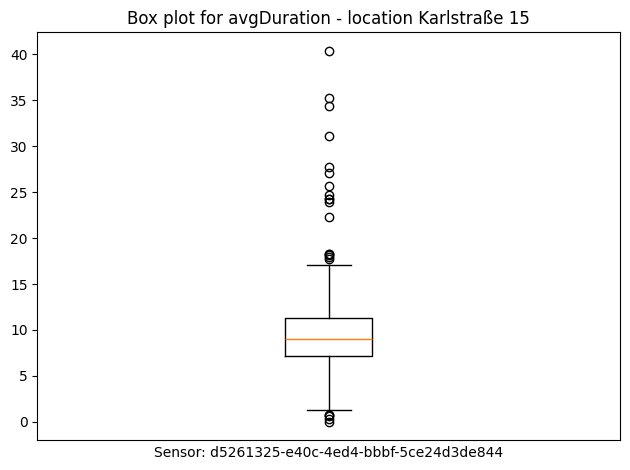

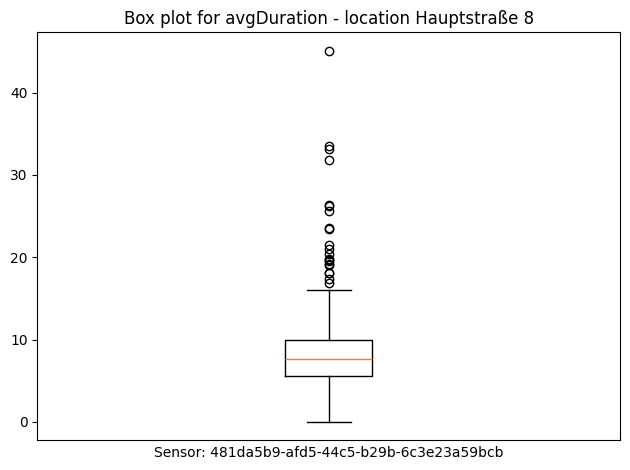

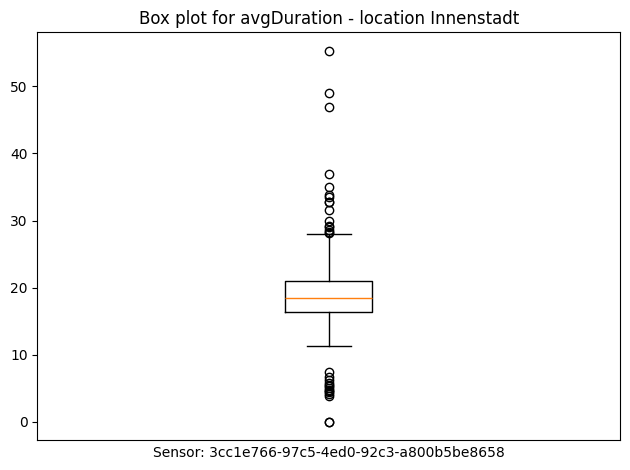

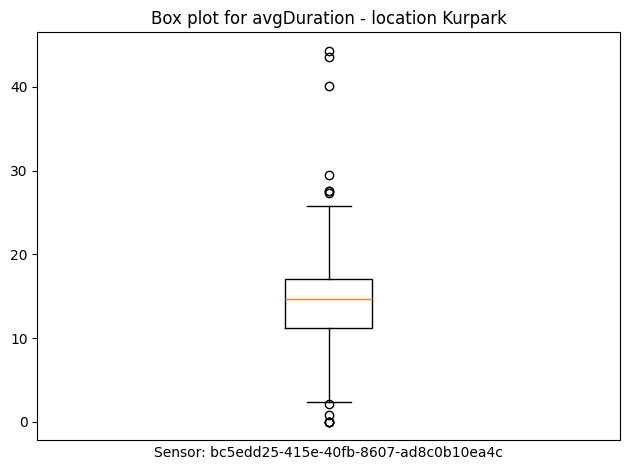

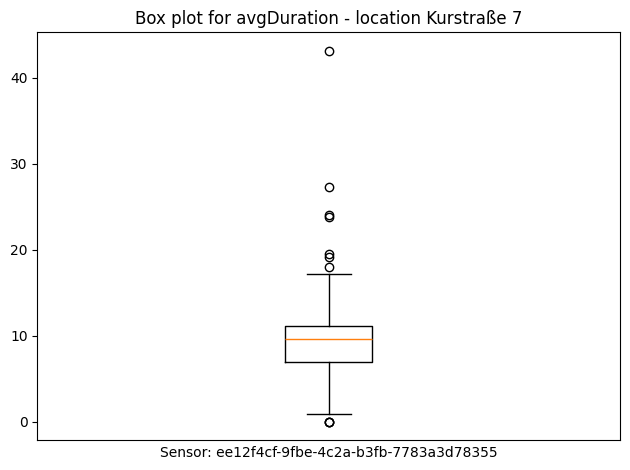

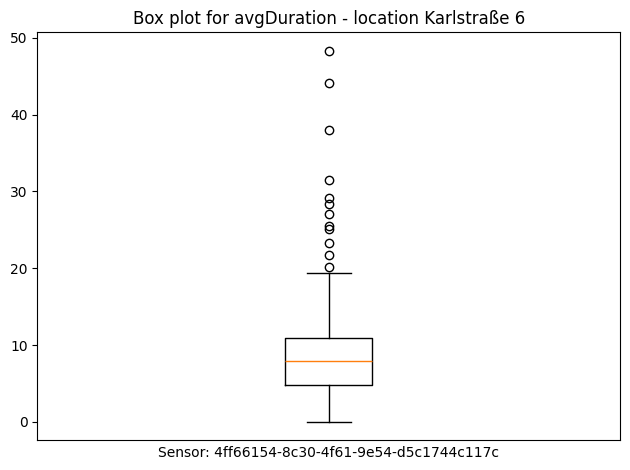

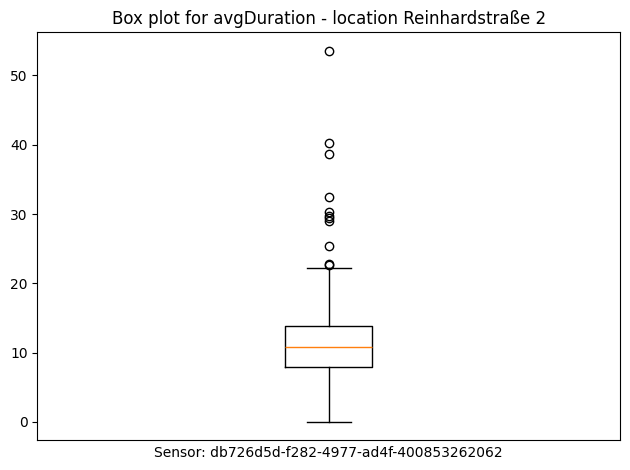

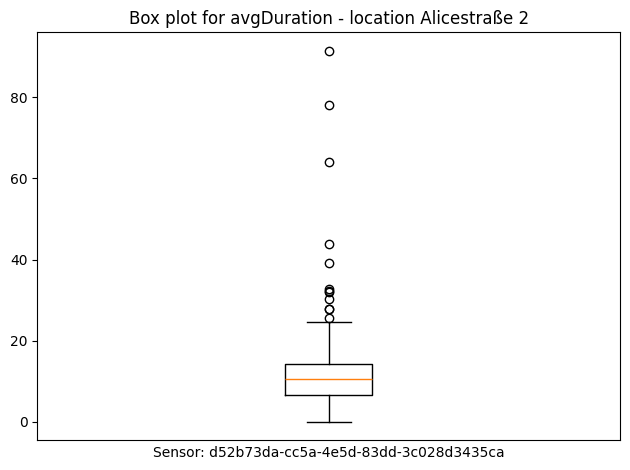

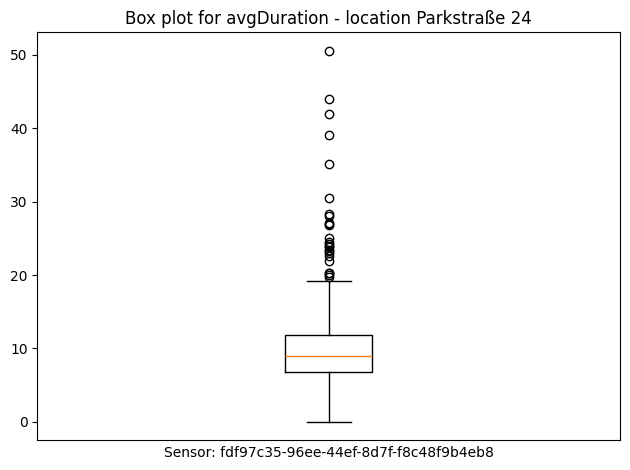

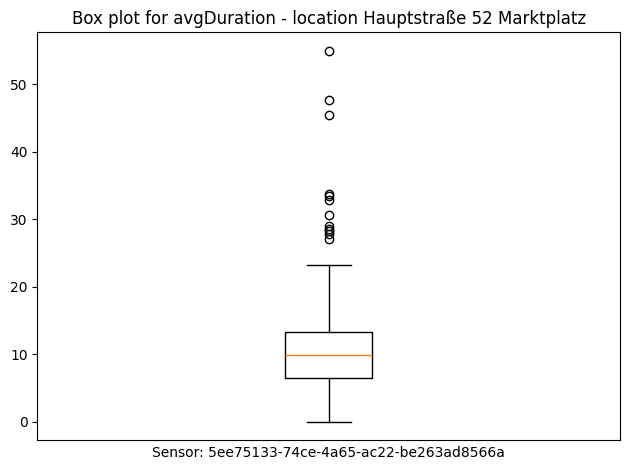

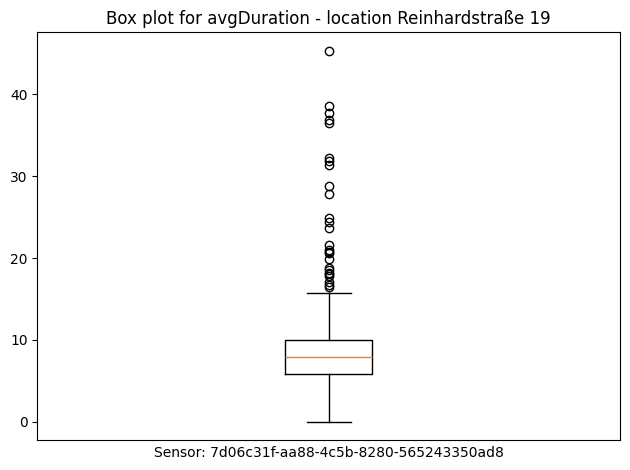

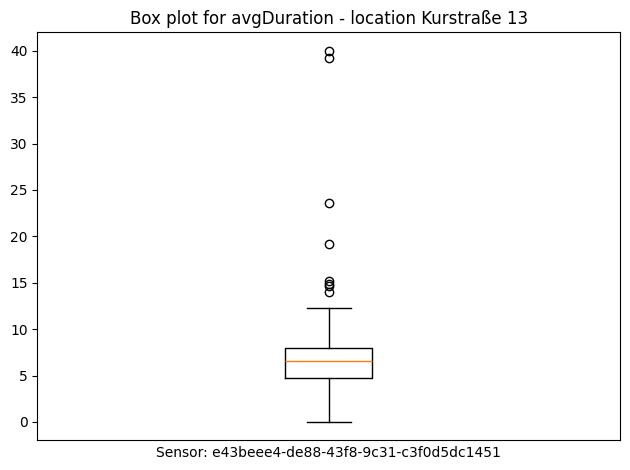

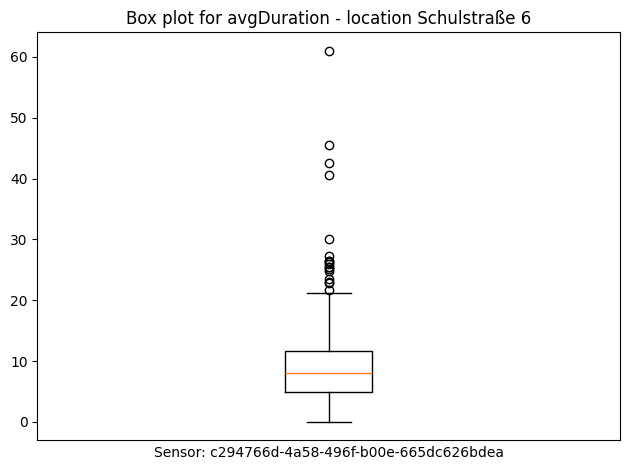

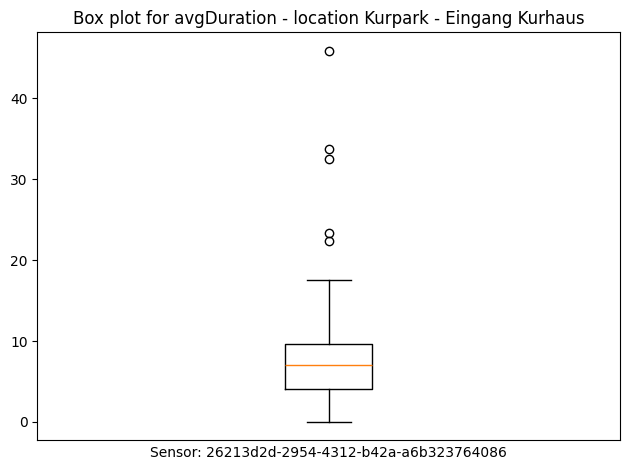

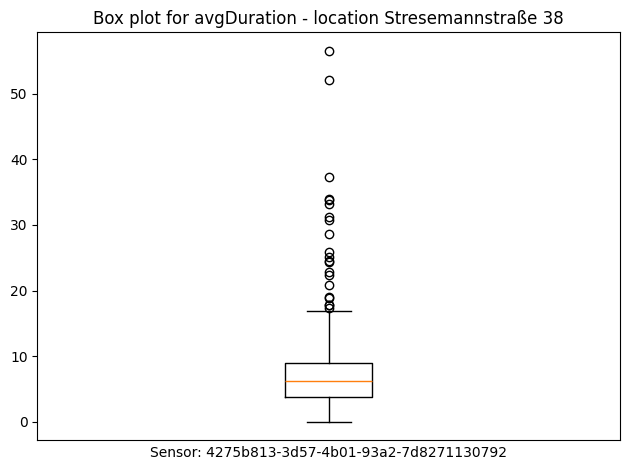

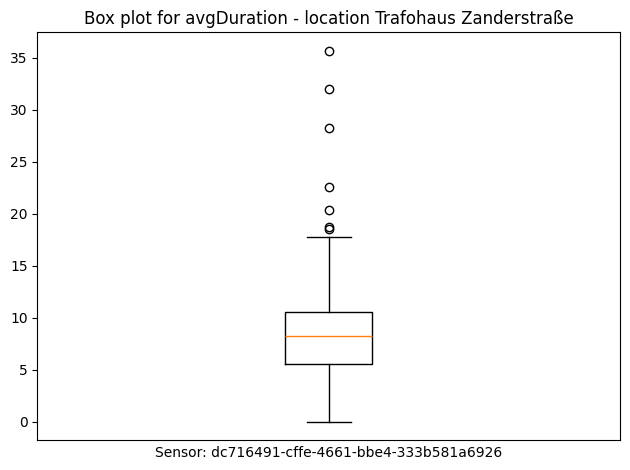

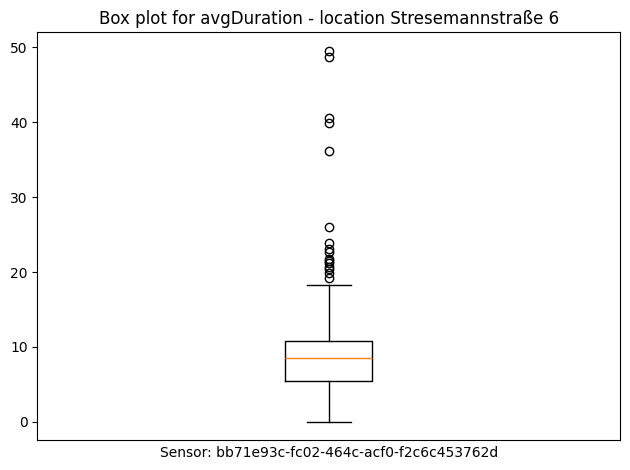

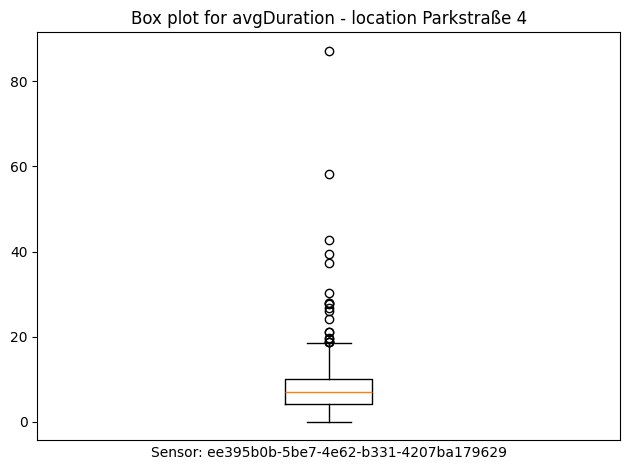

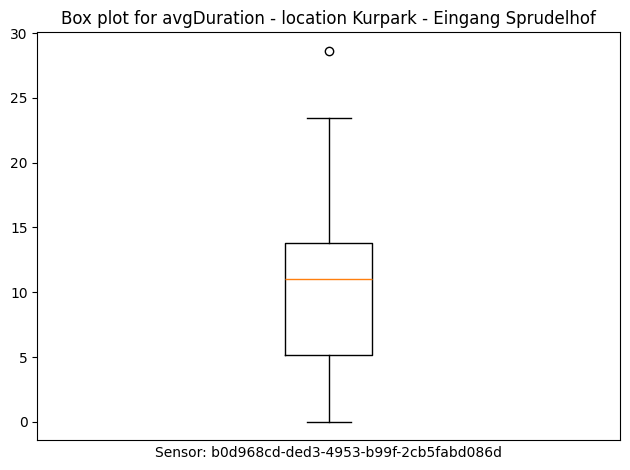

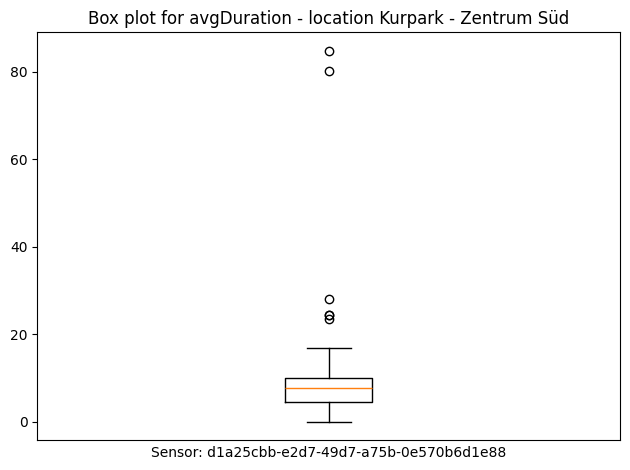

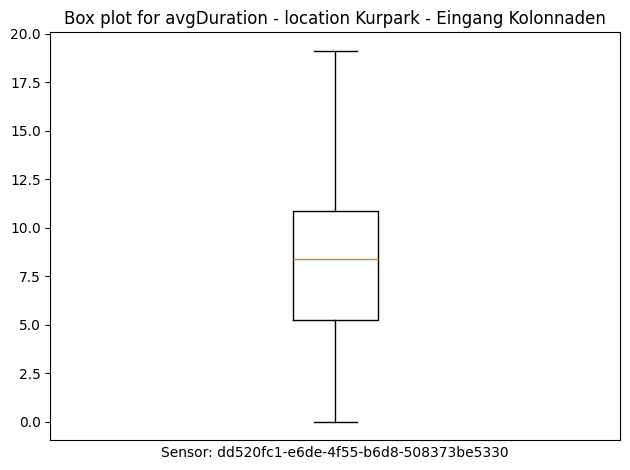

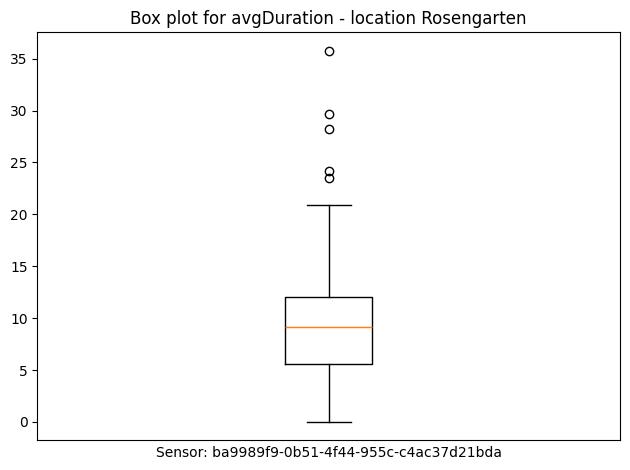

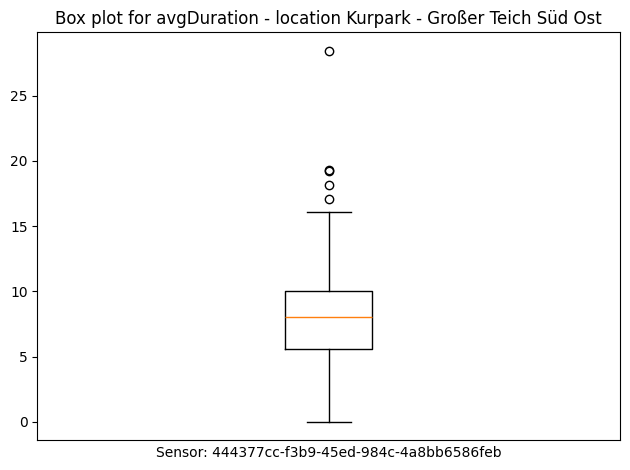

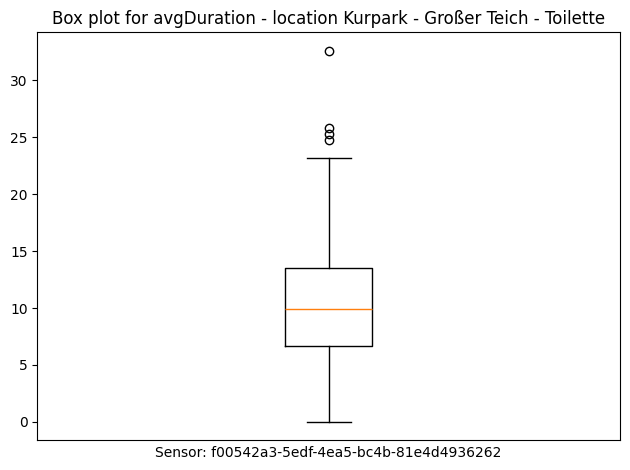

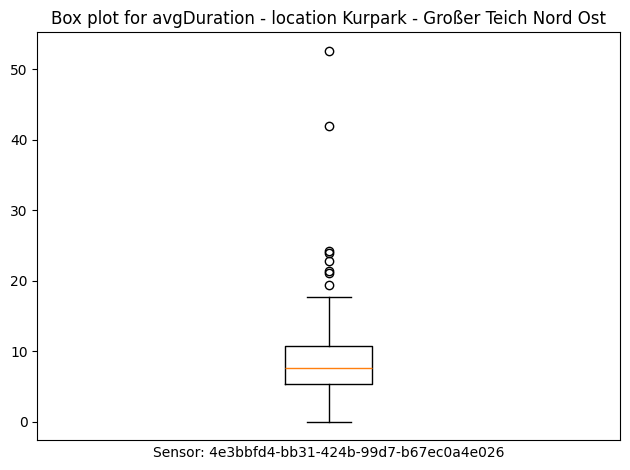

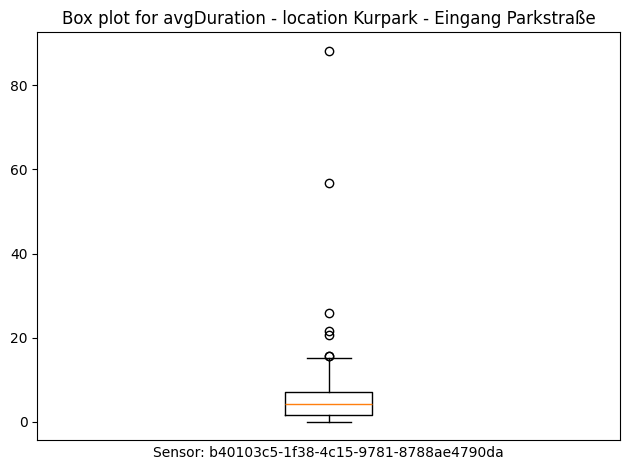

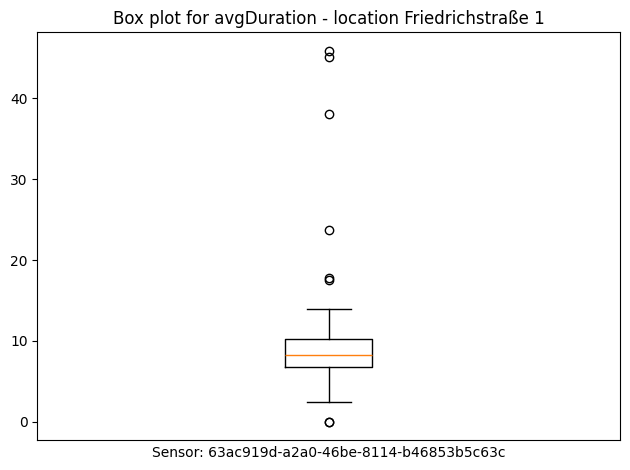

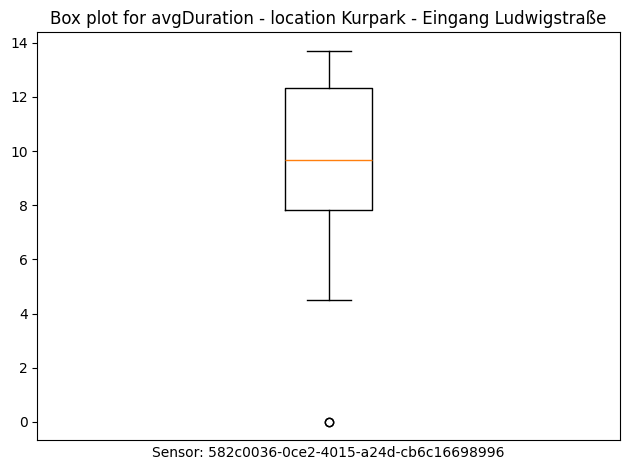

In [29]:
for sensor in sensors:
    boxplot_analysis_averageDuration(sensor)

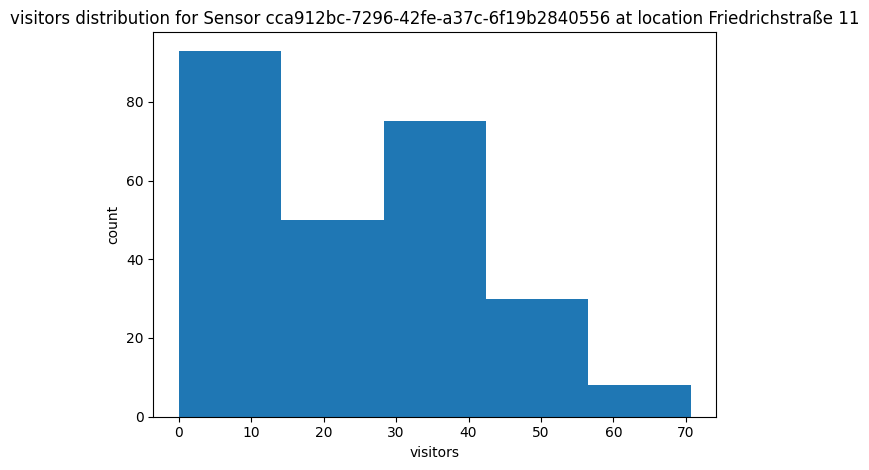

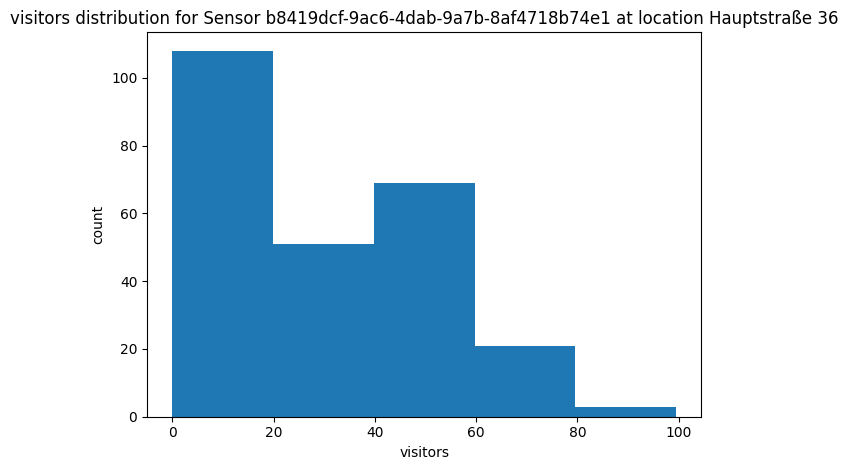

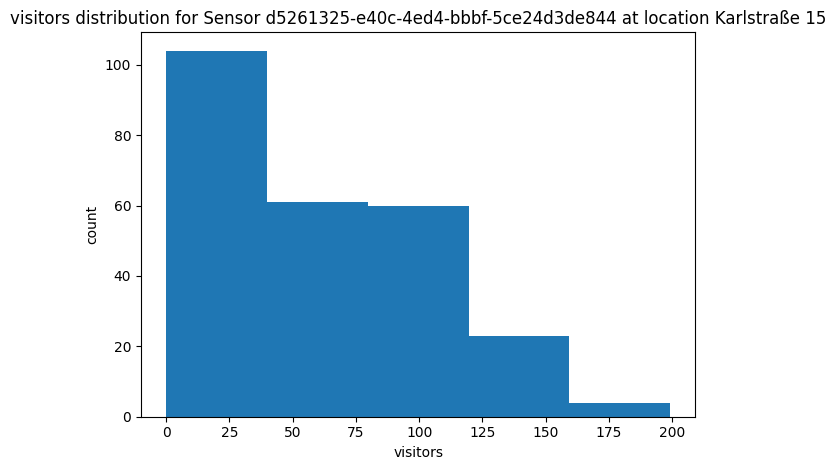

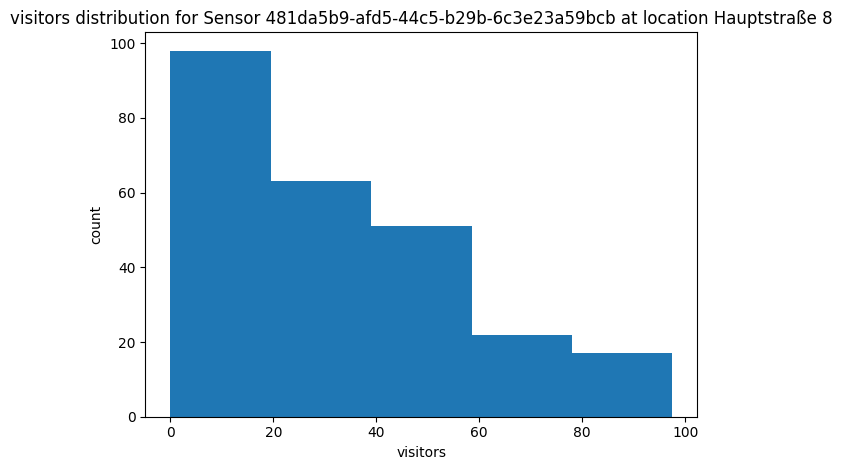

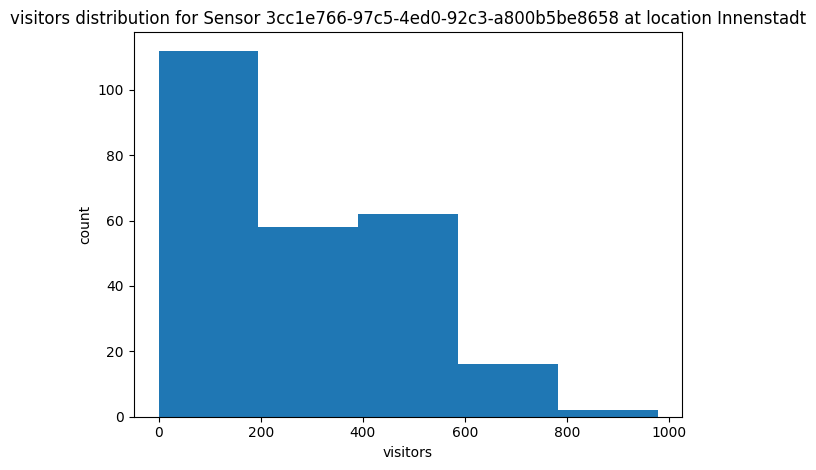

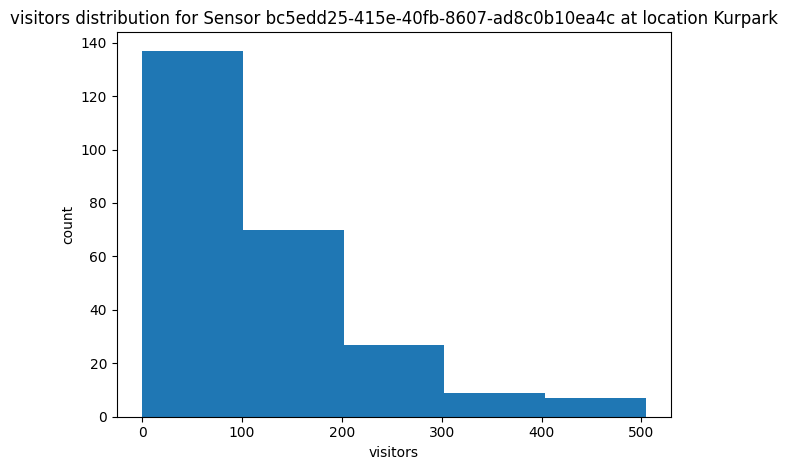

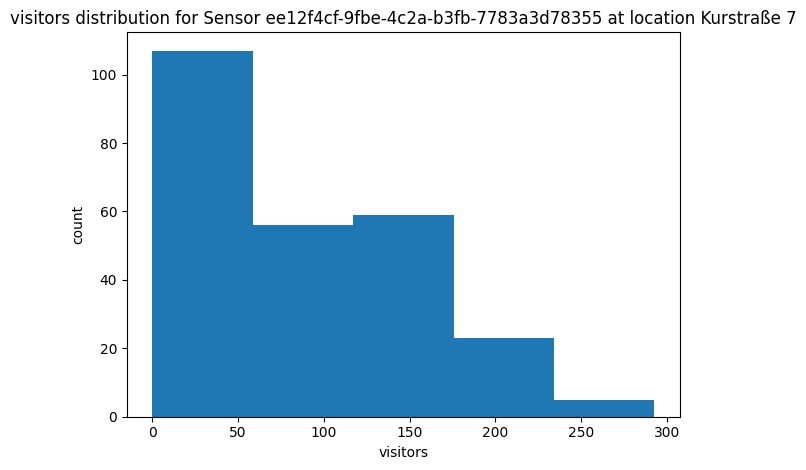

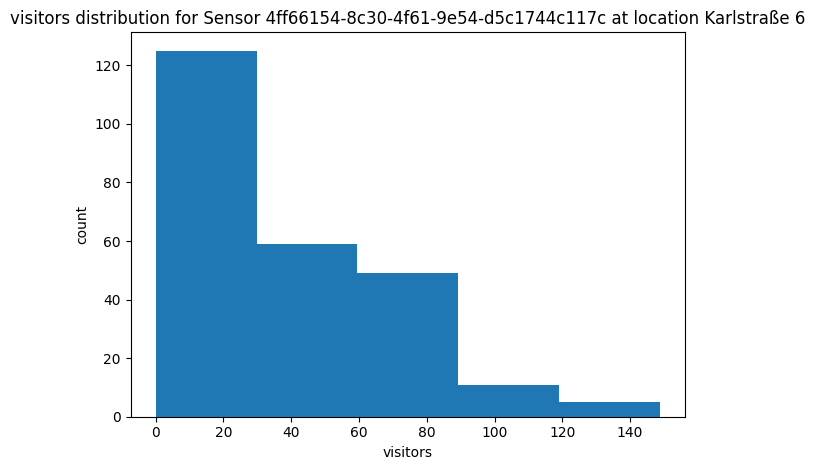

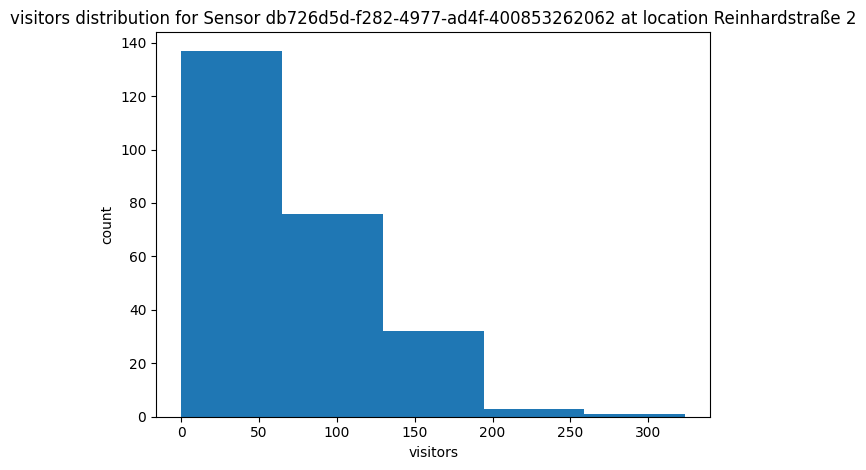

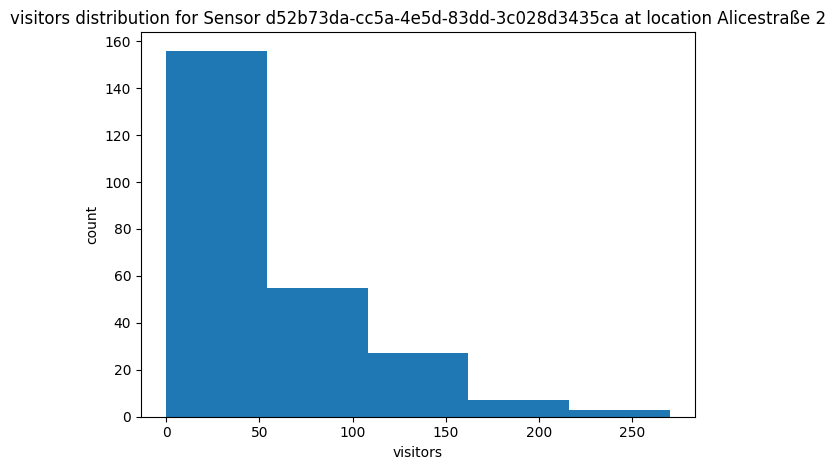

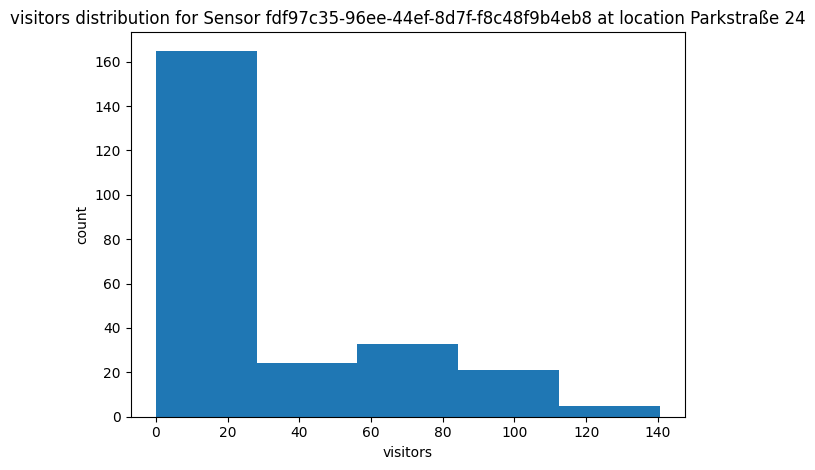

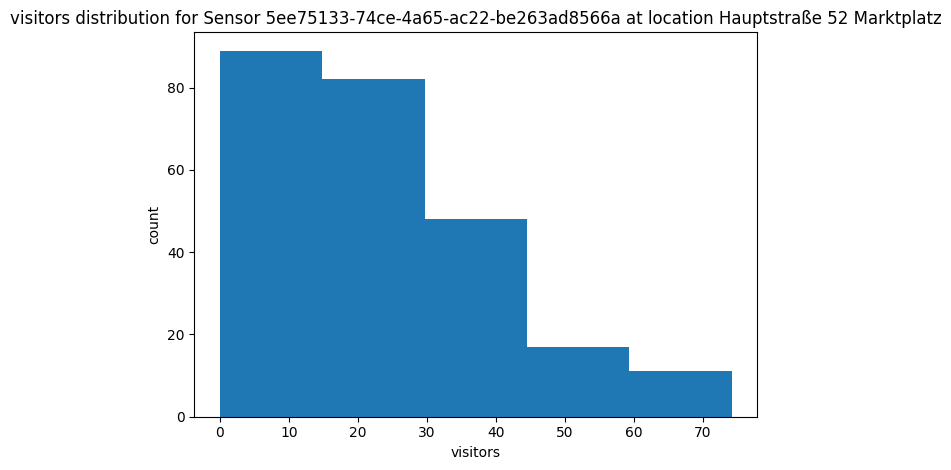

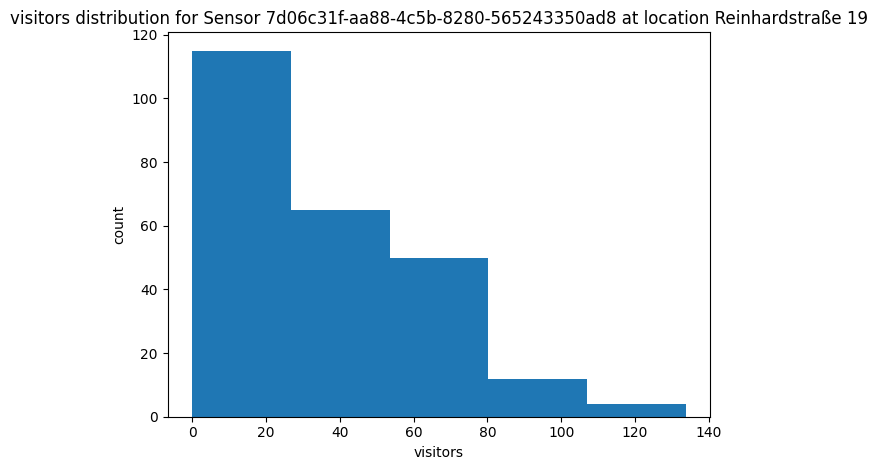

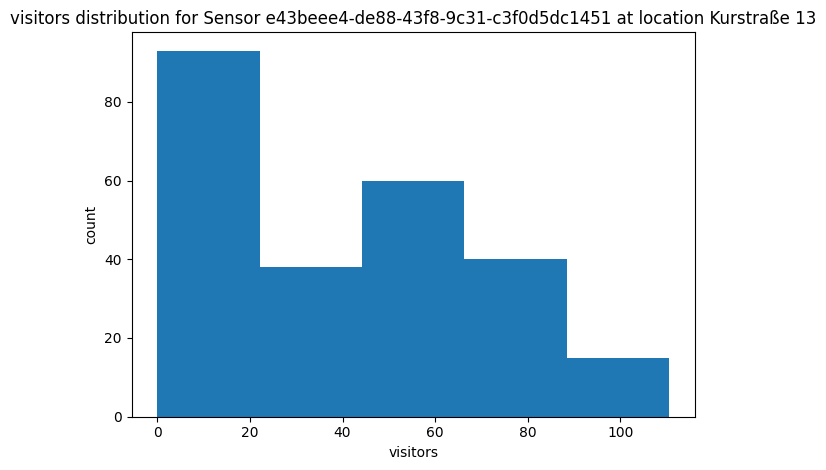

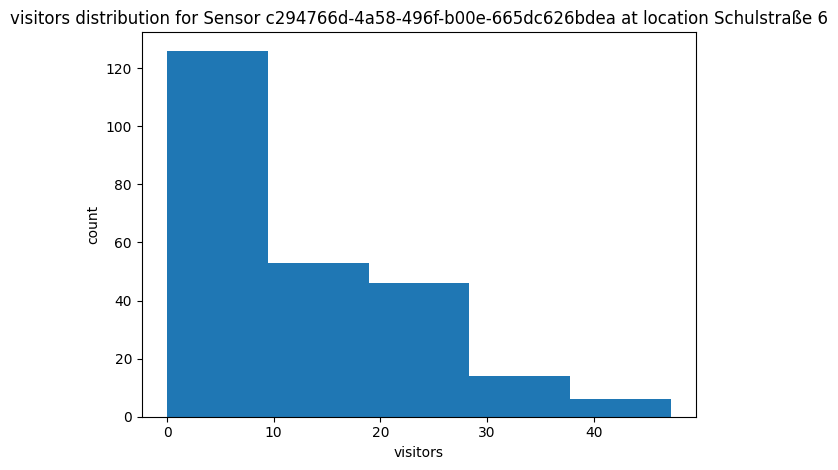

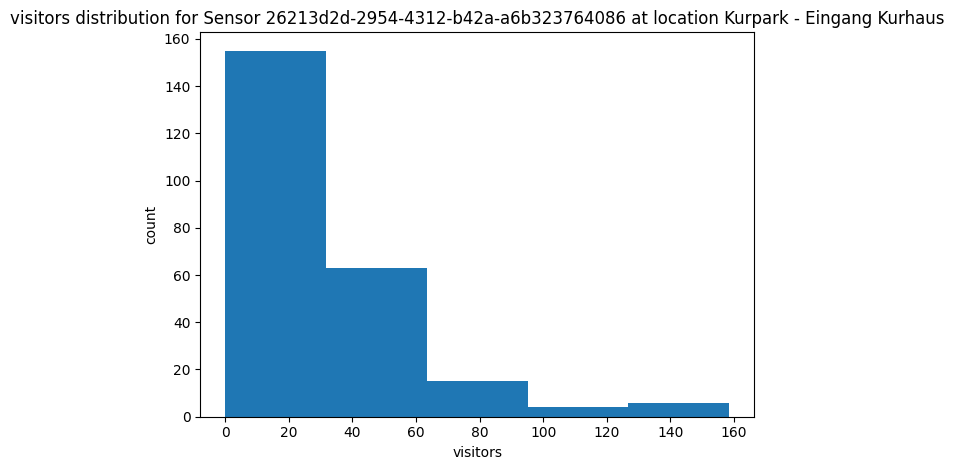

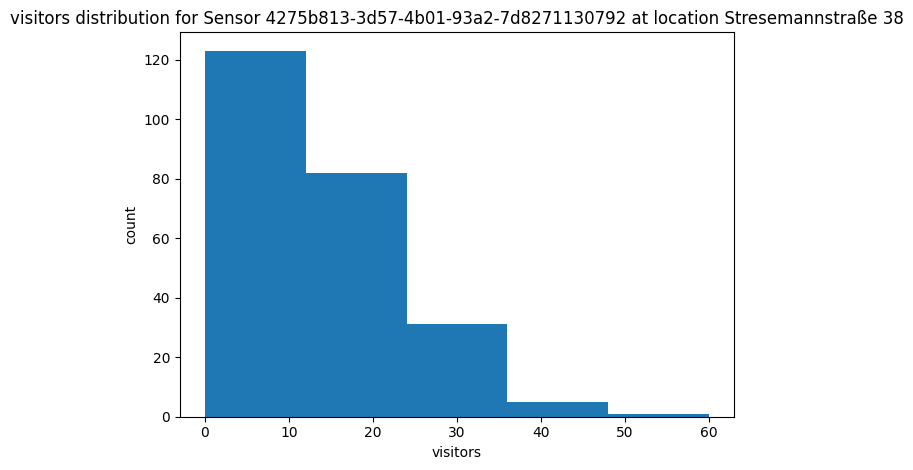

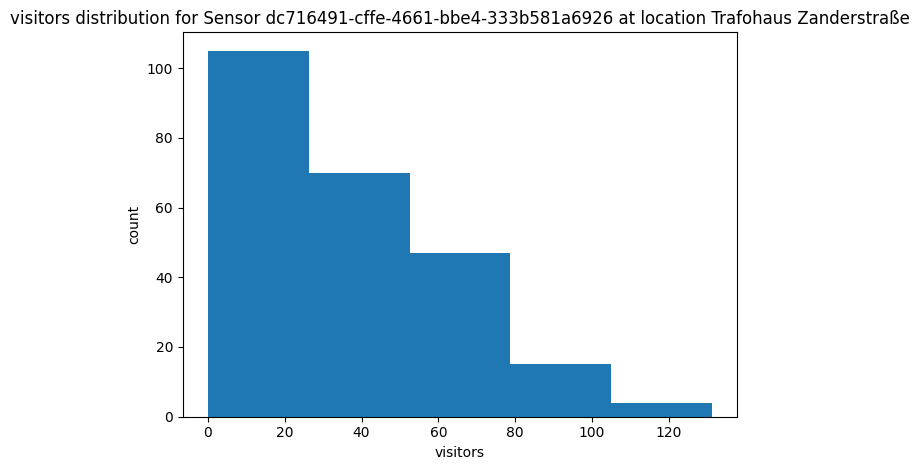

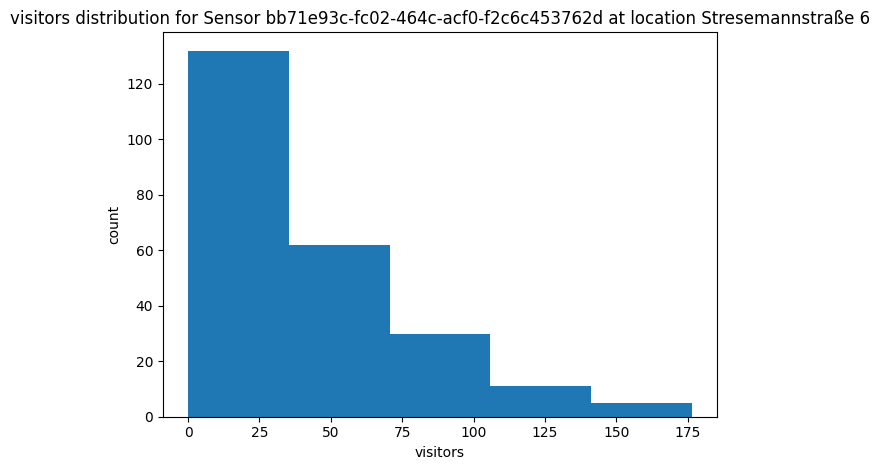

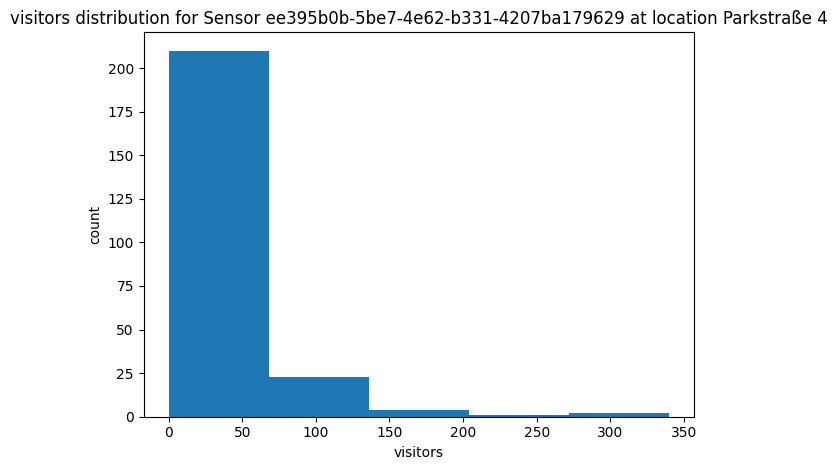

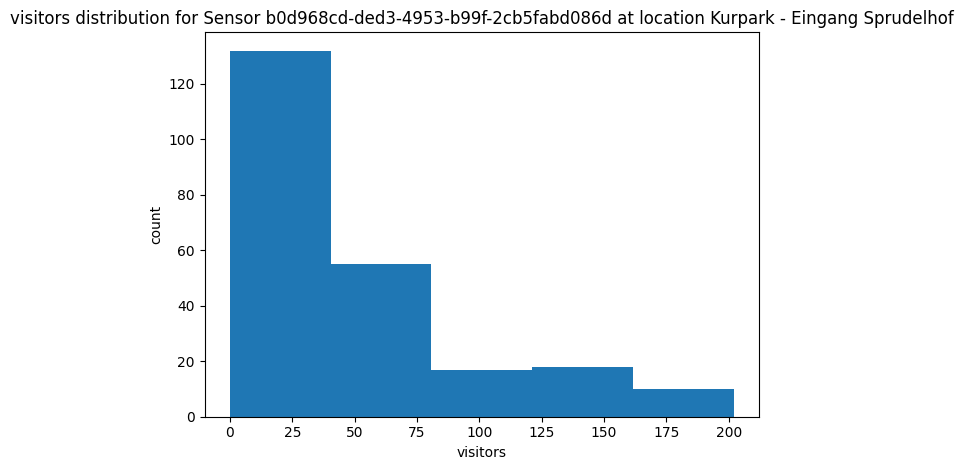

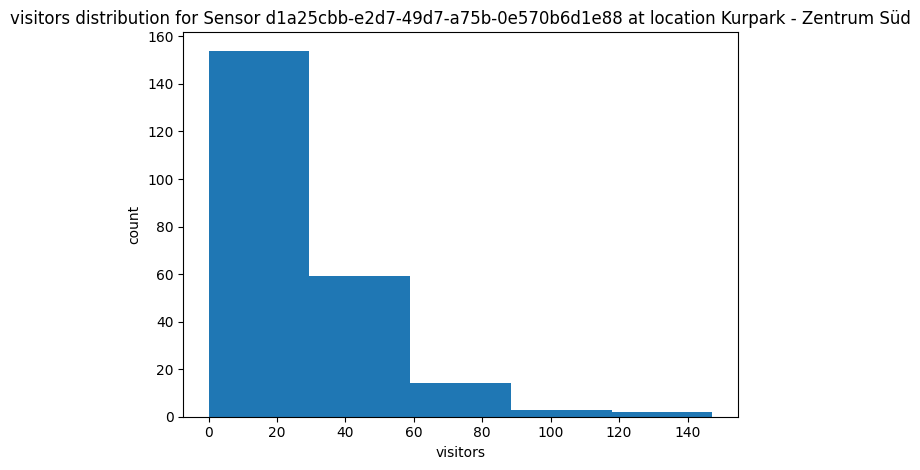

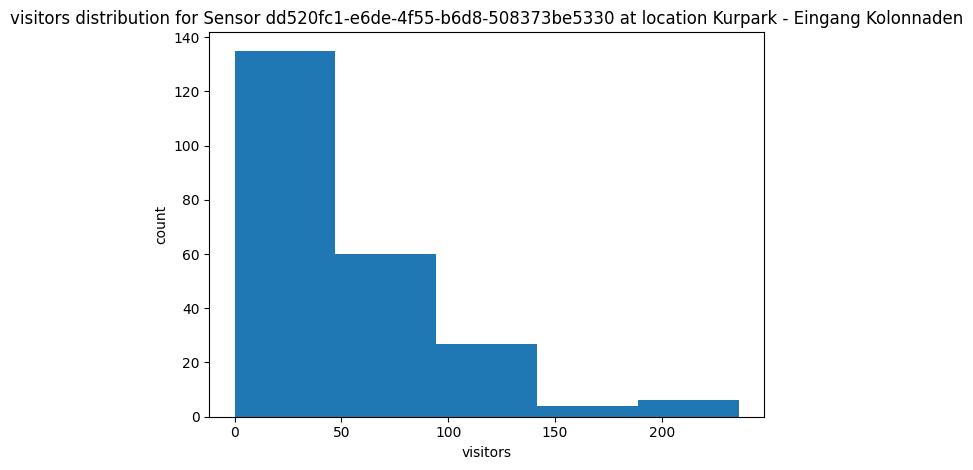

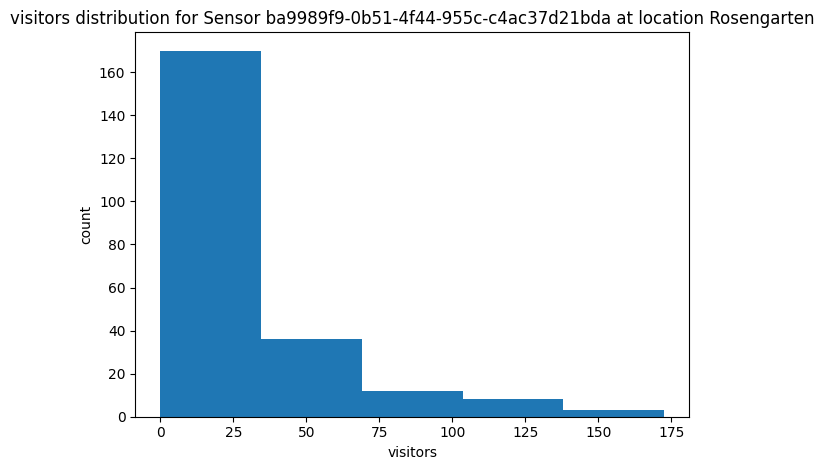

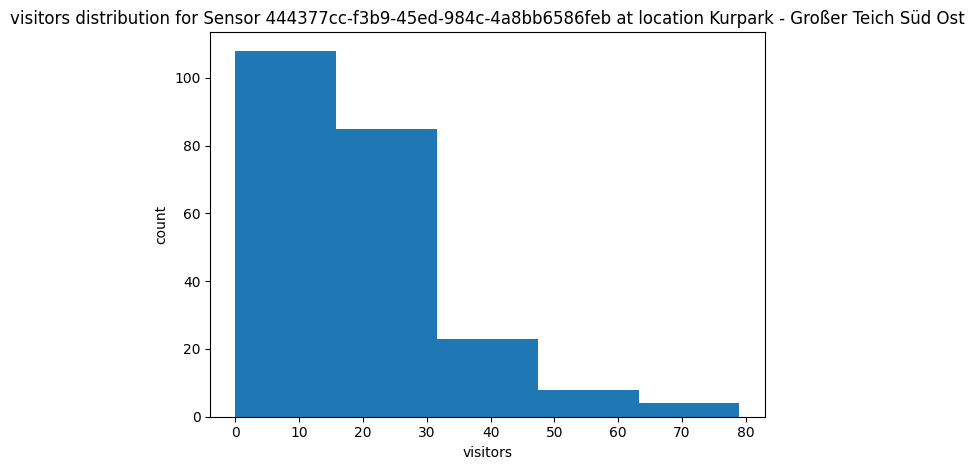

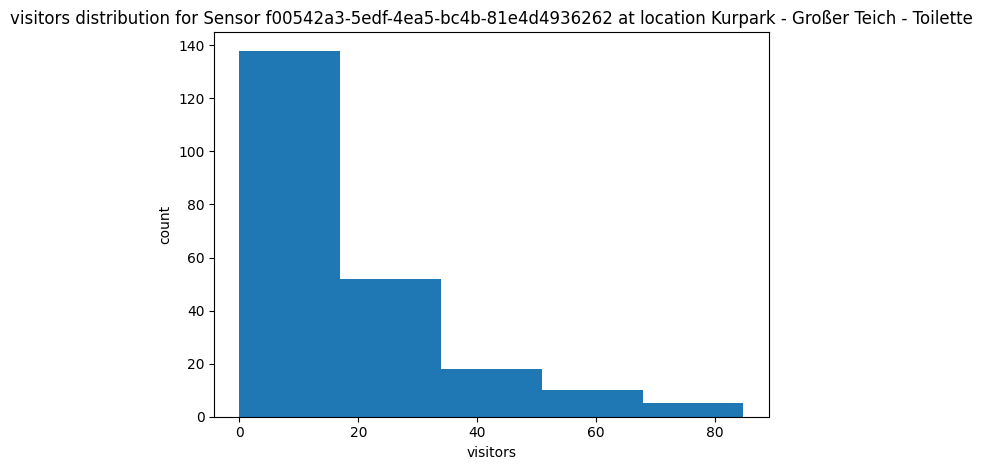

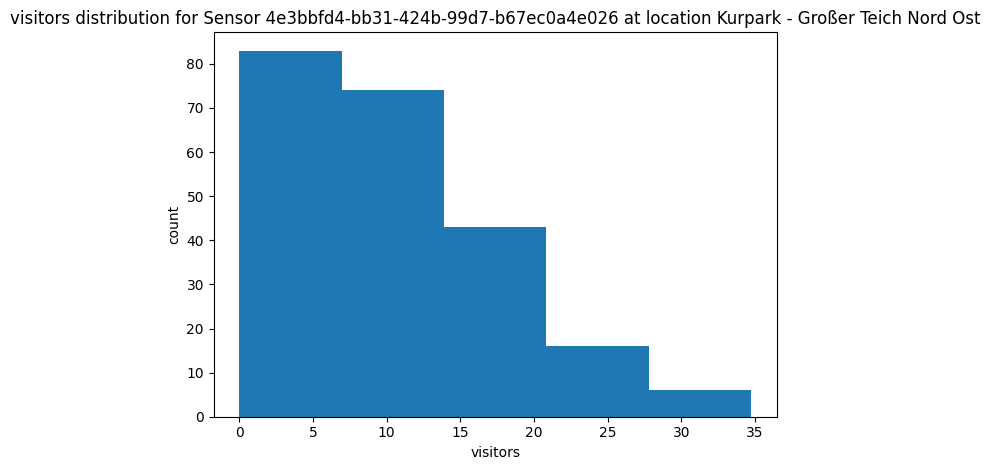

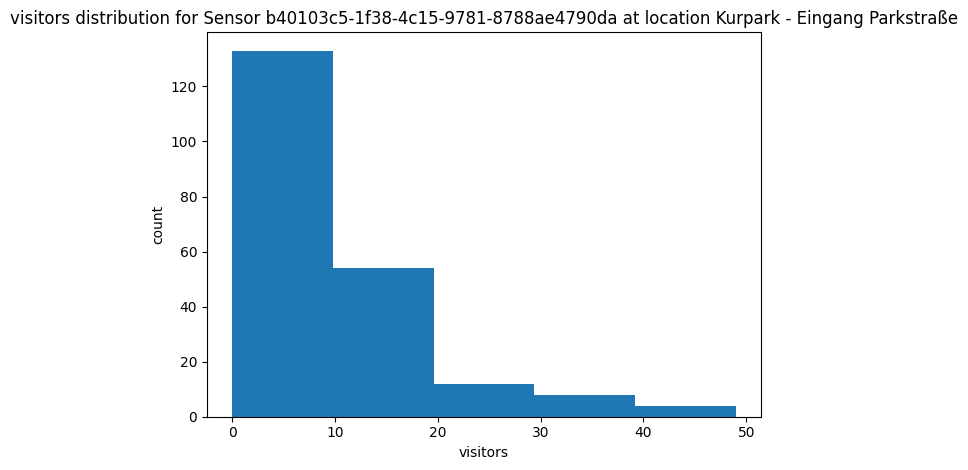

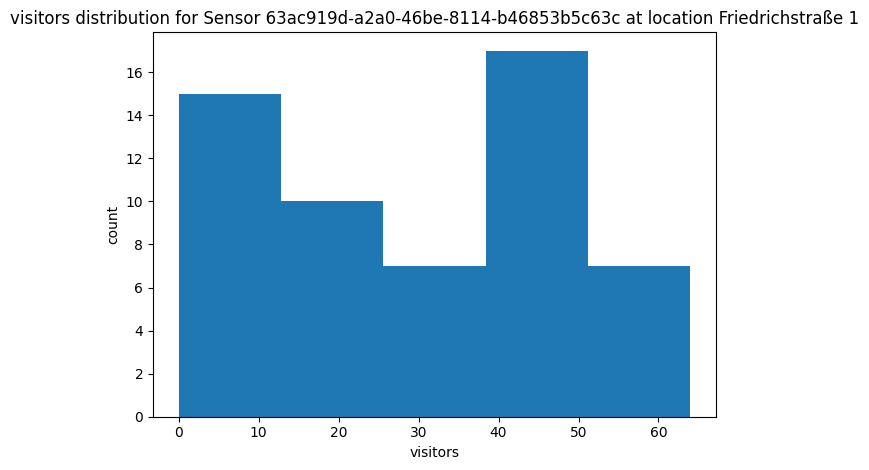

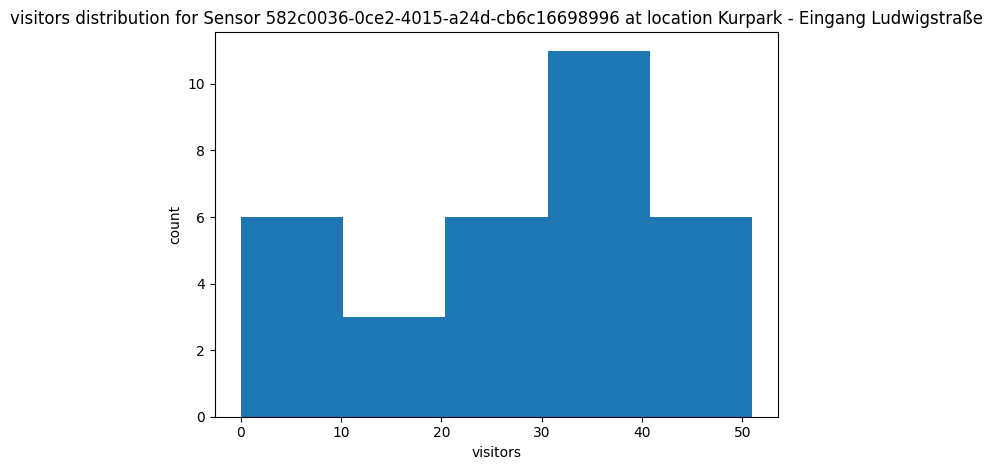

In [30]:
for sensor in sensors:
    vistors_data_distribution(sensor)

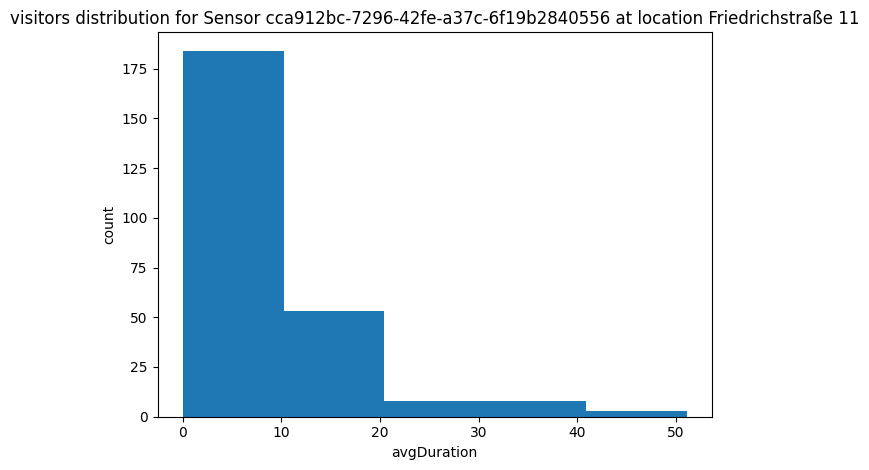

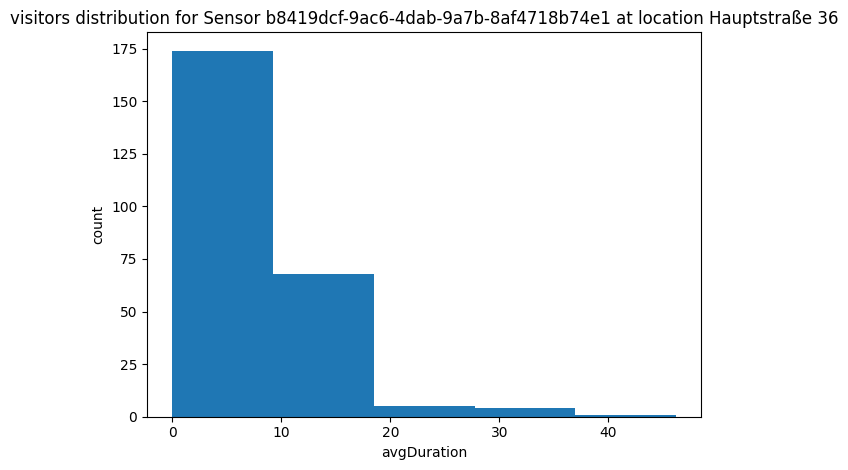

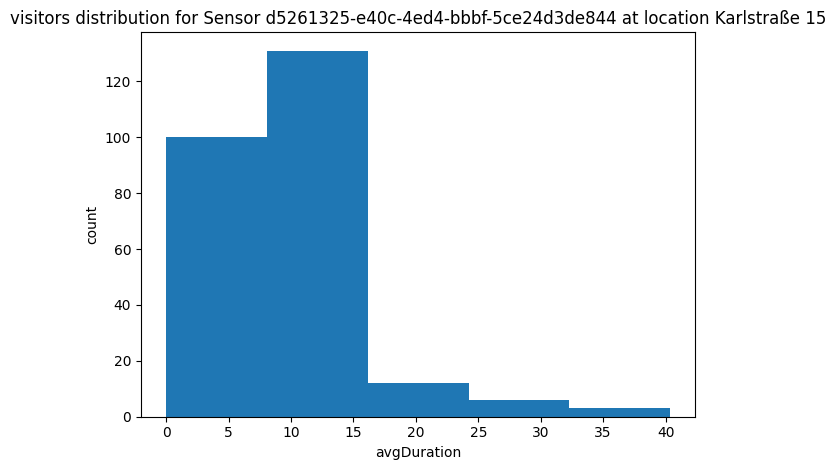

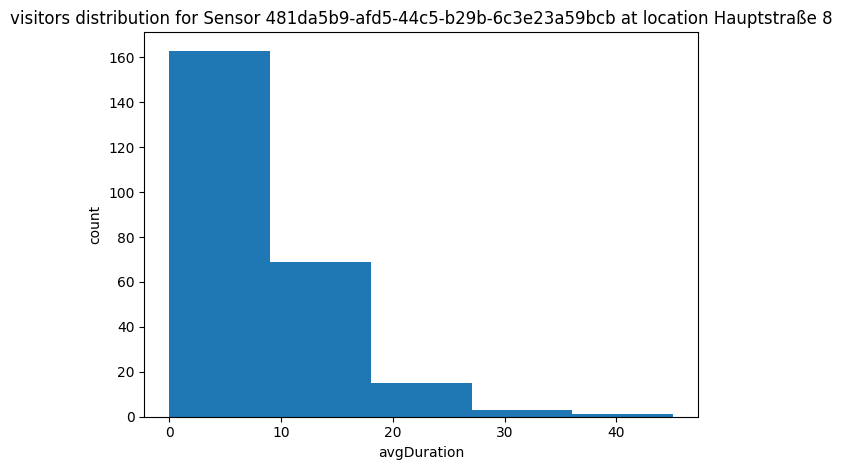

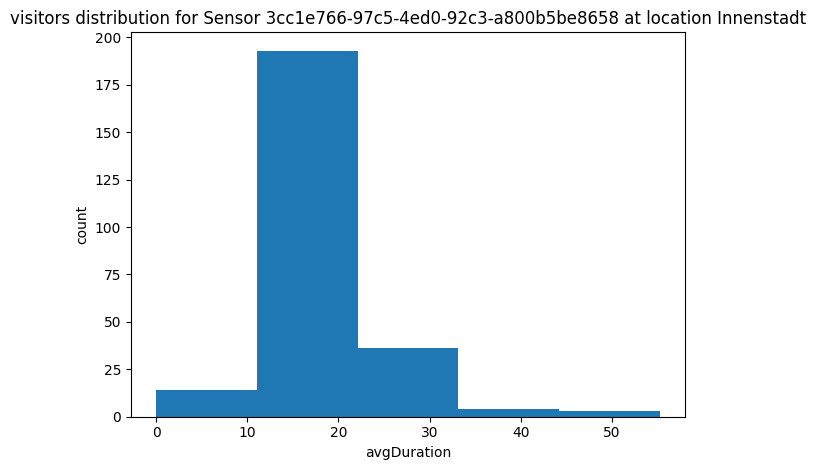

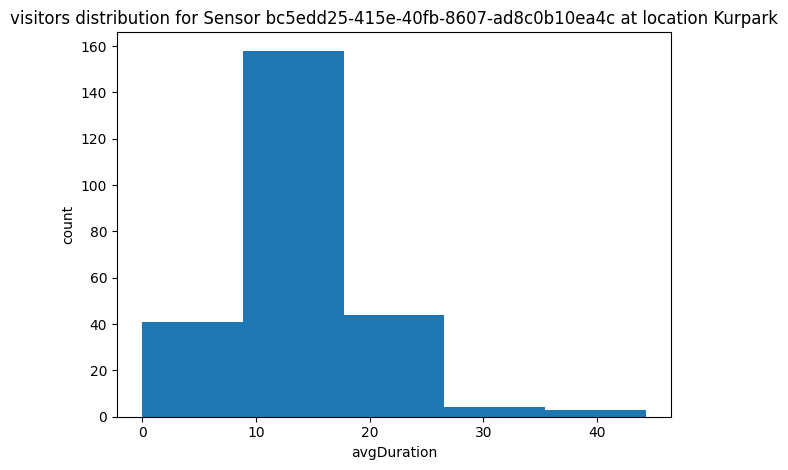

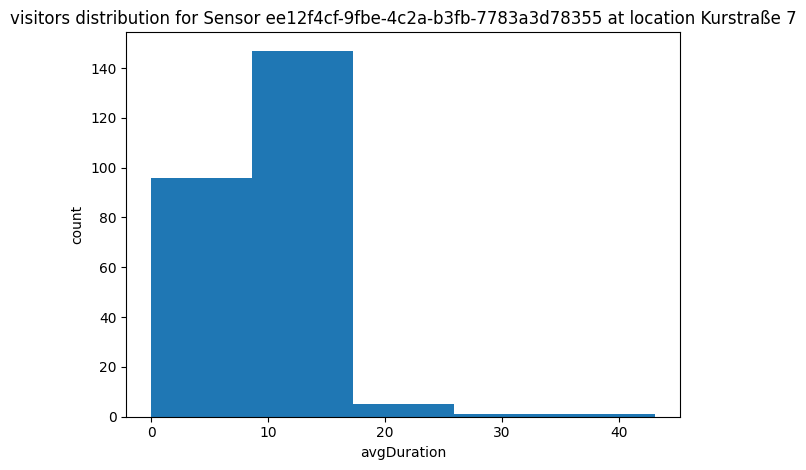

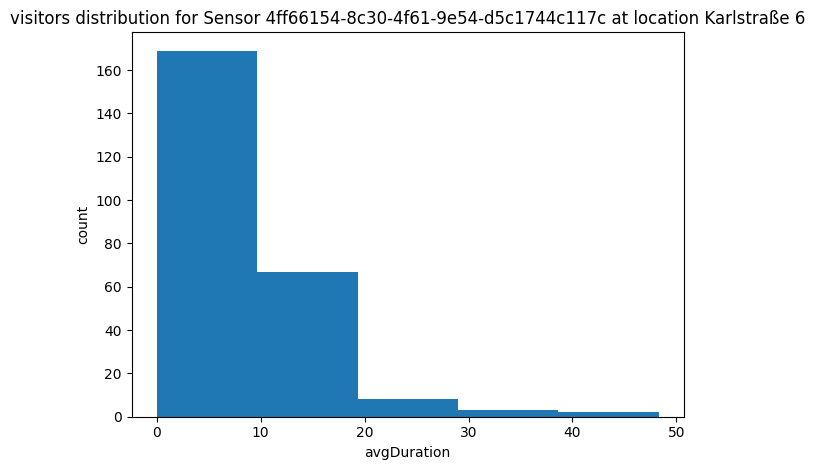

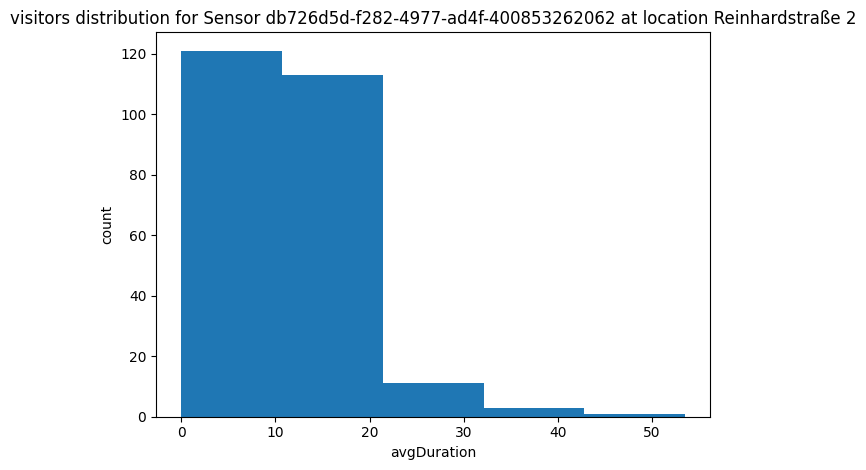

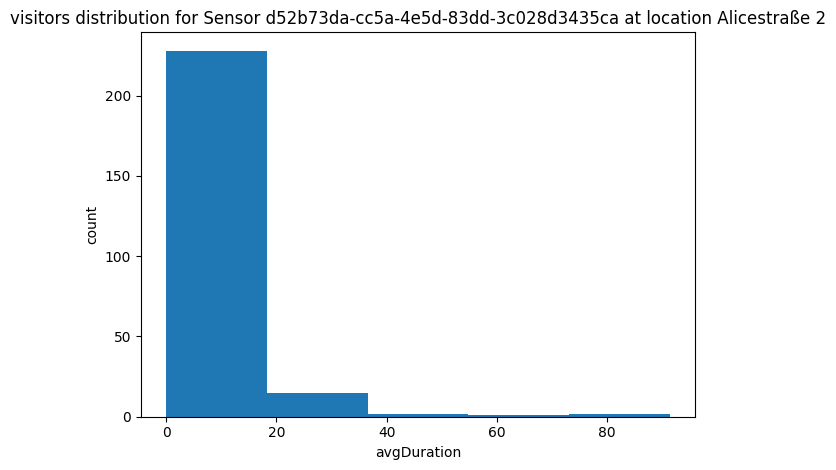

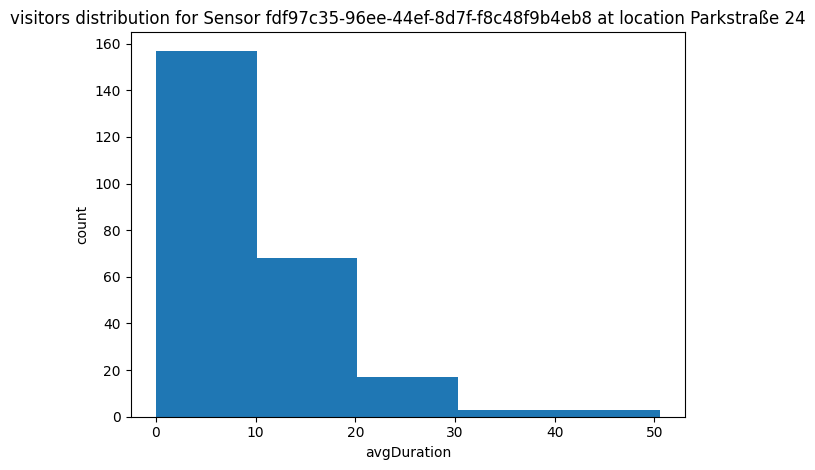

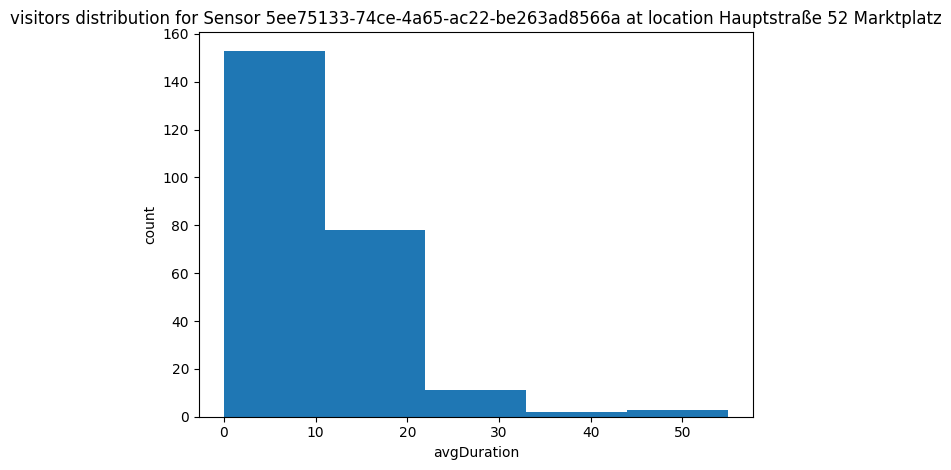

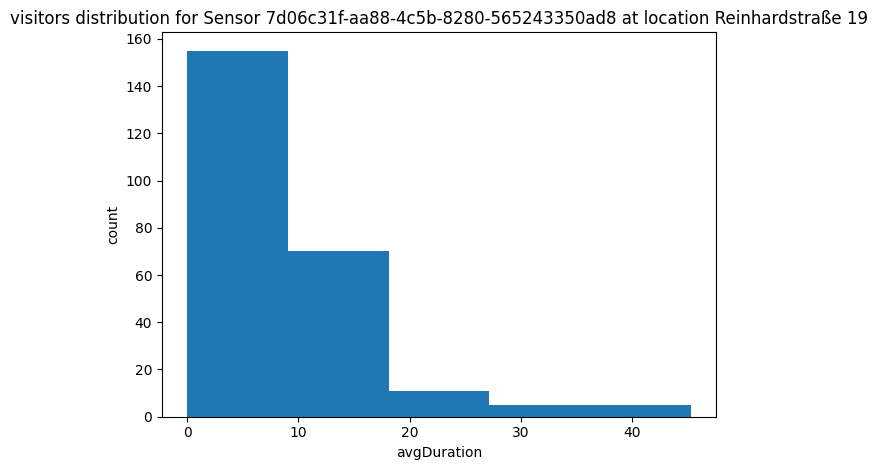

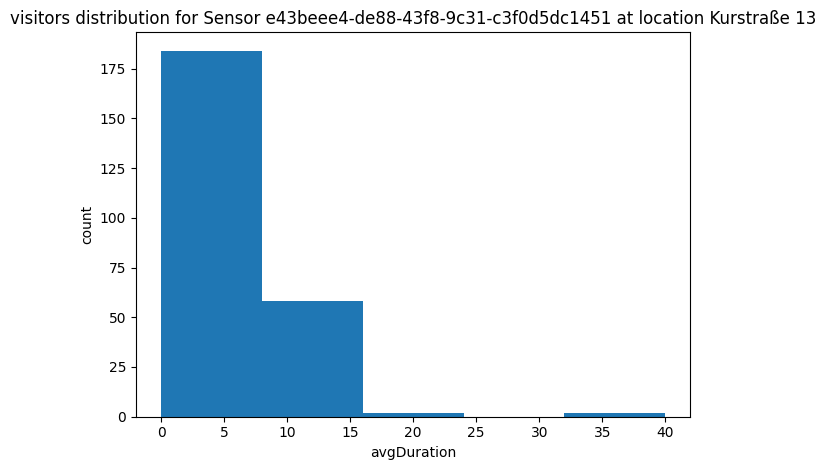

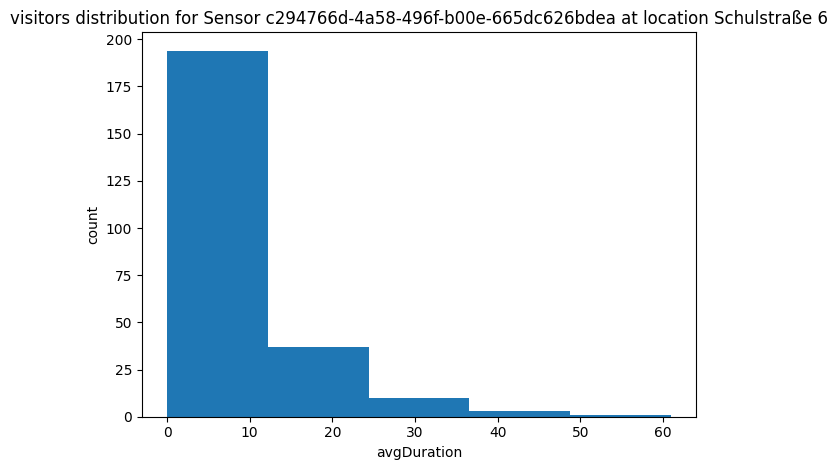

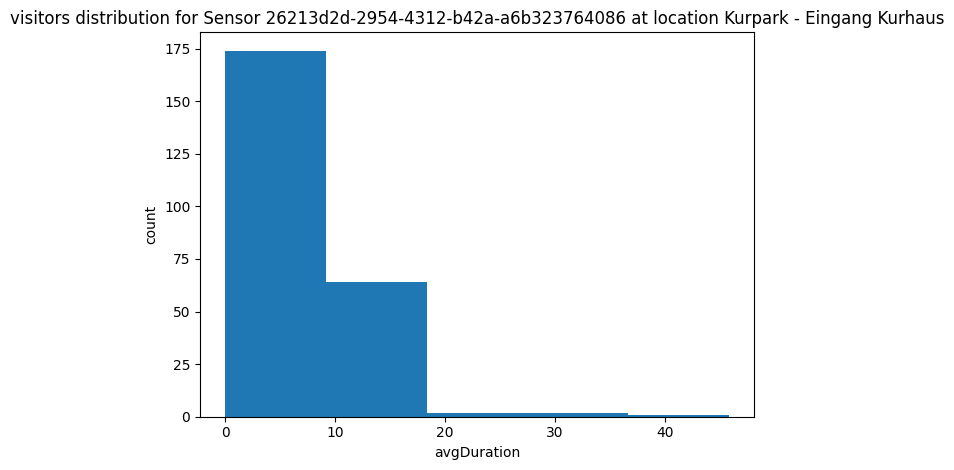

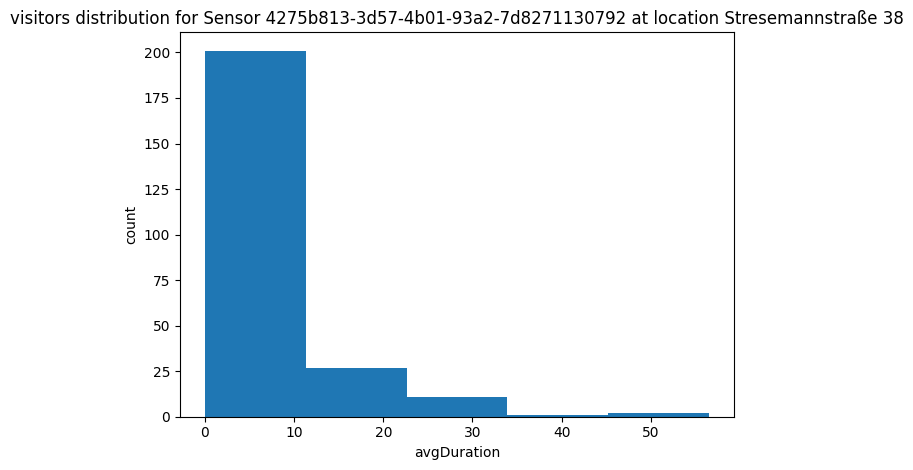

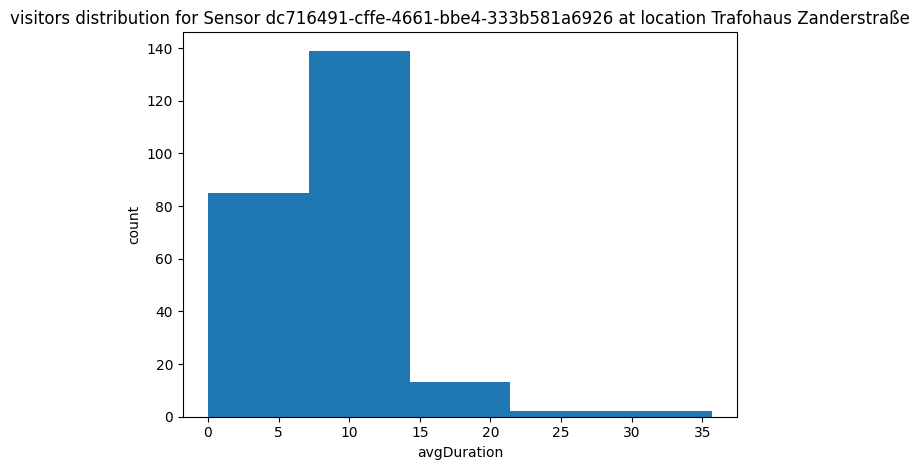

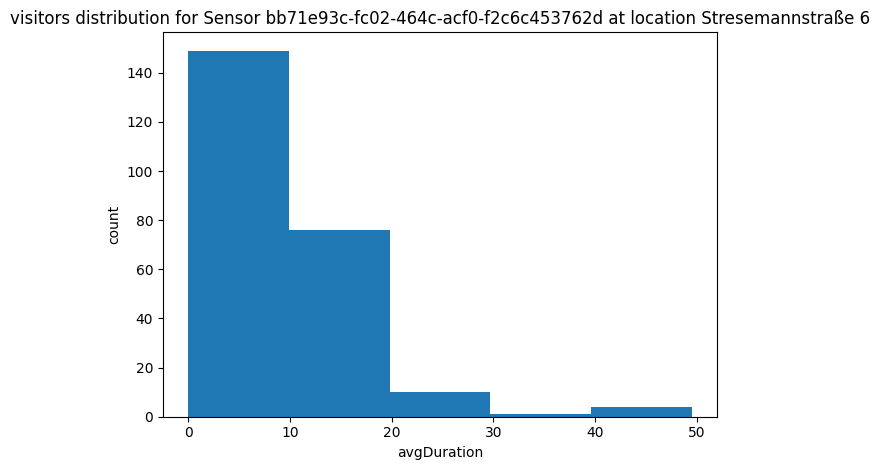

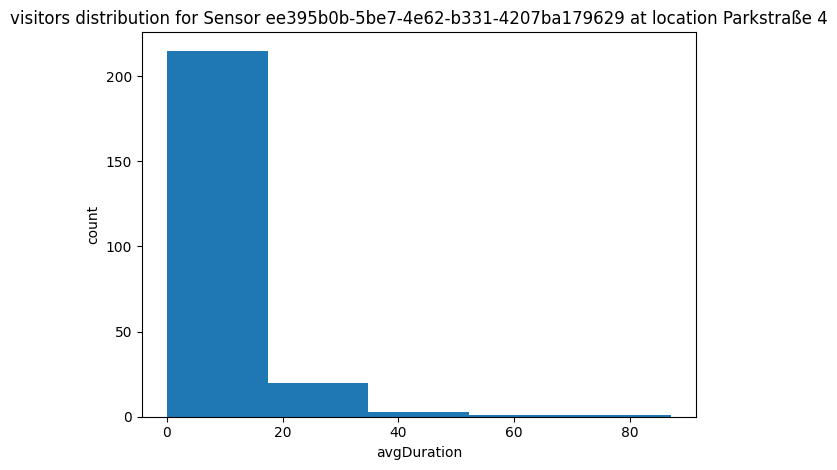

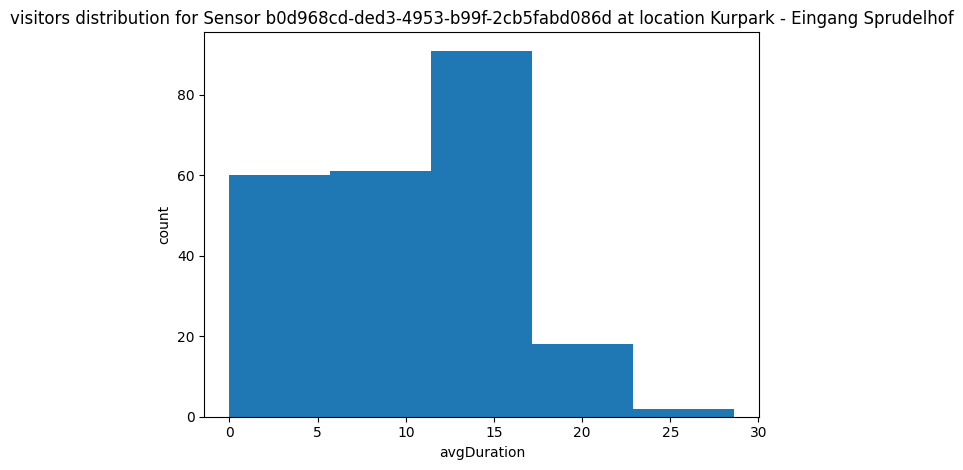

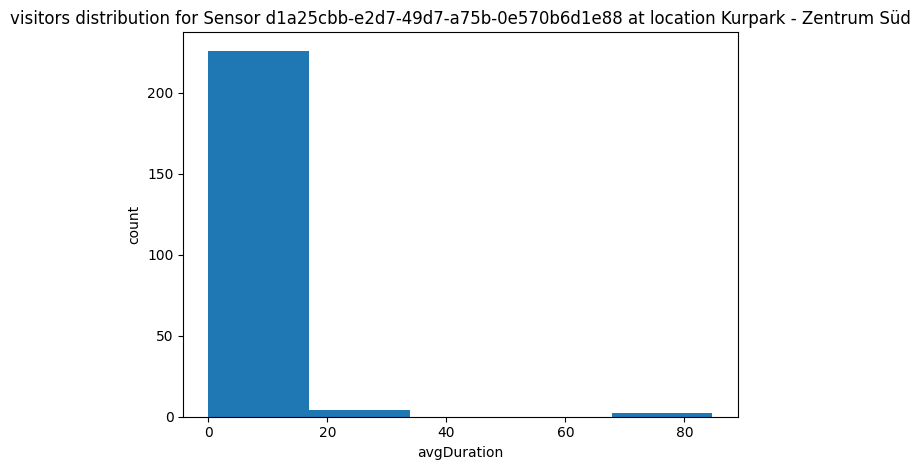

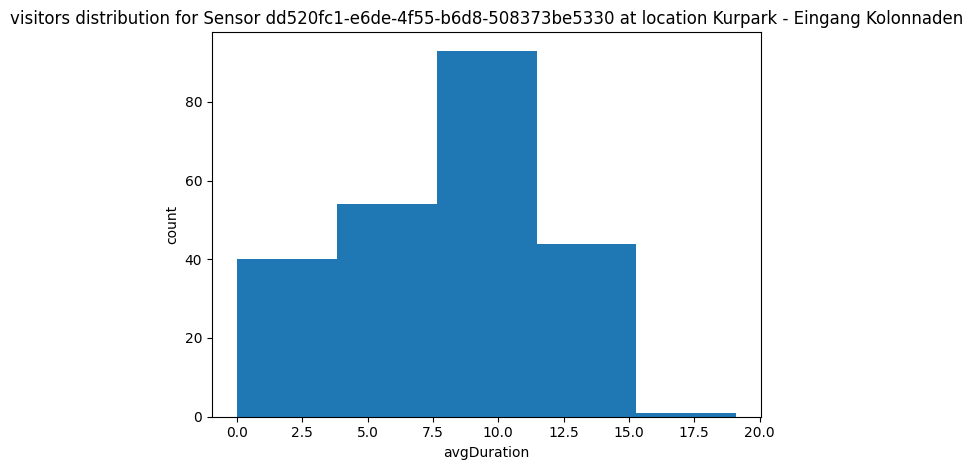

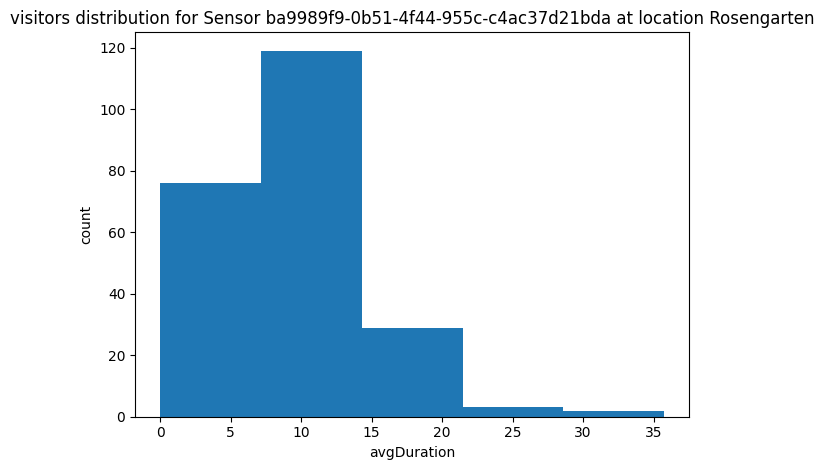

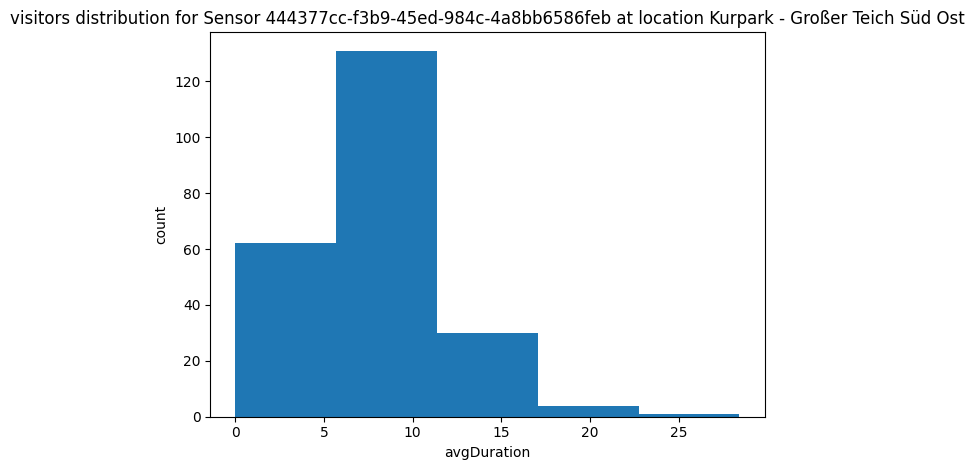

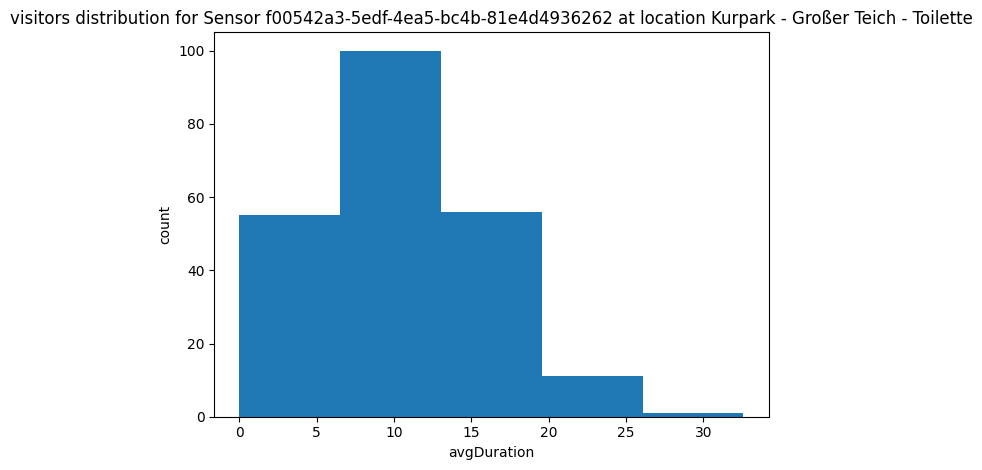

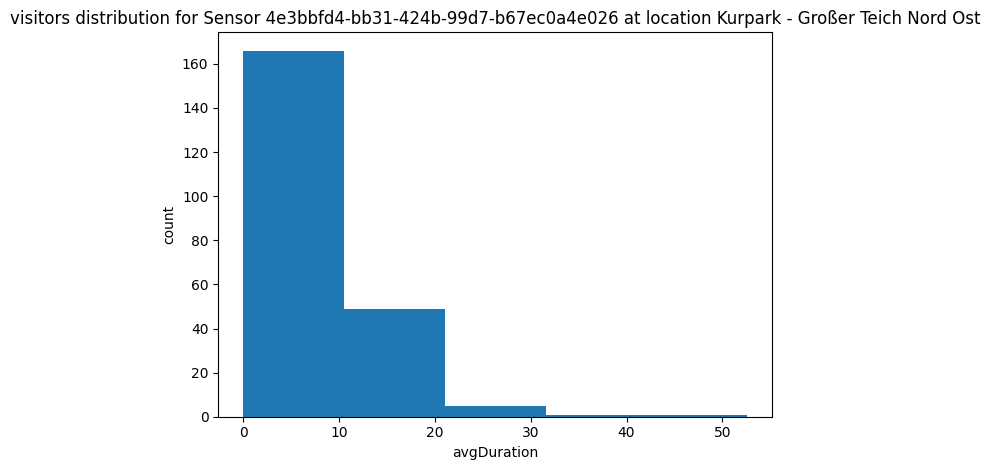

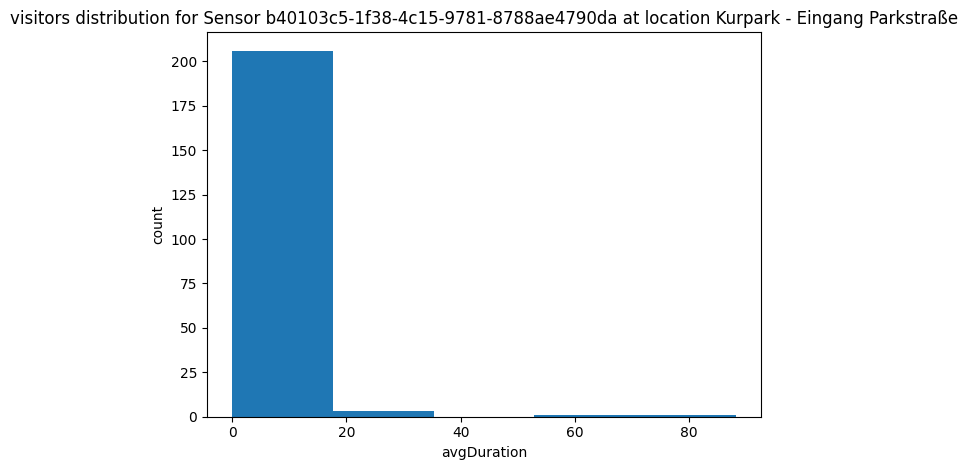

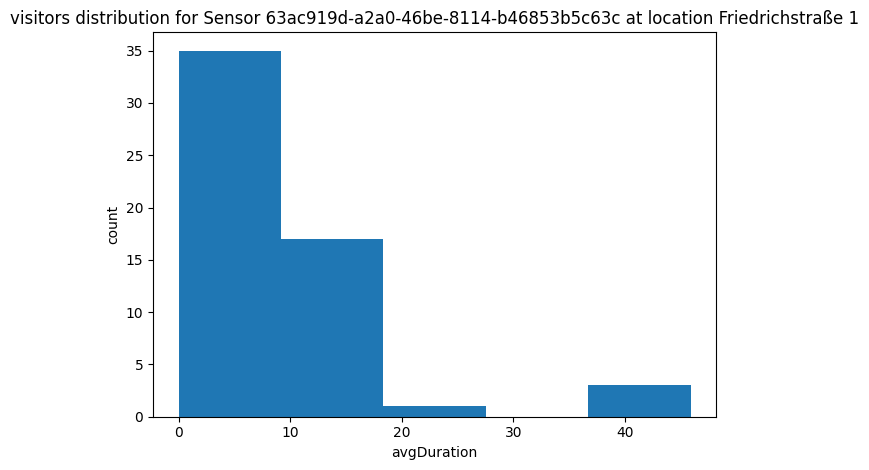

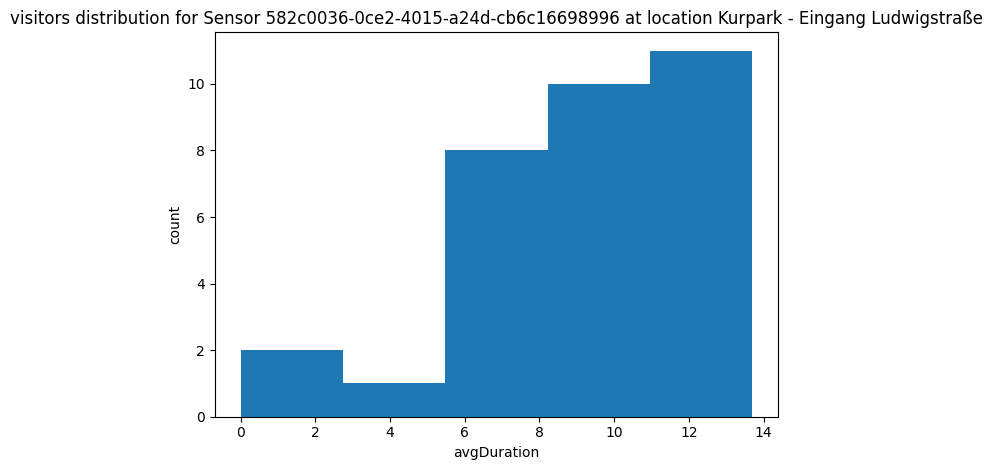

In [31]:
for sensor in sensors:
    avgDuration_data_distribution(sensor)

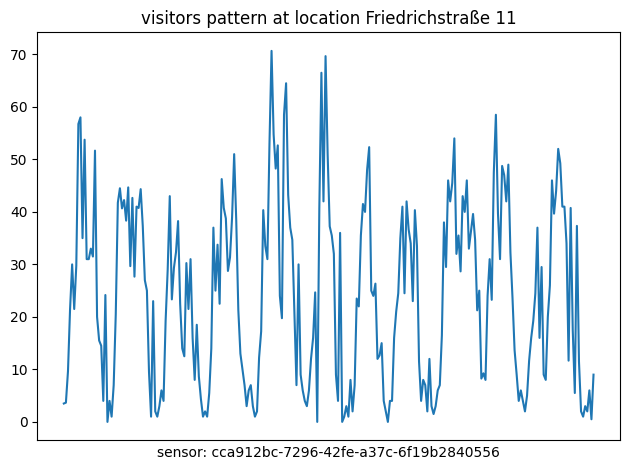

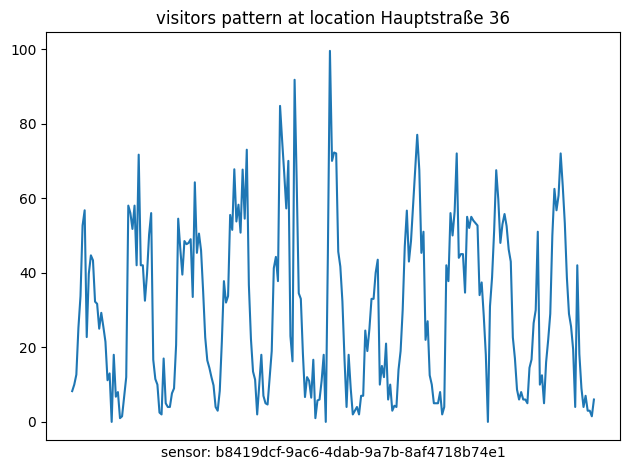

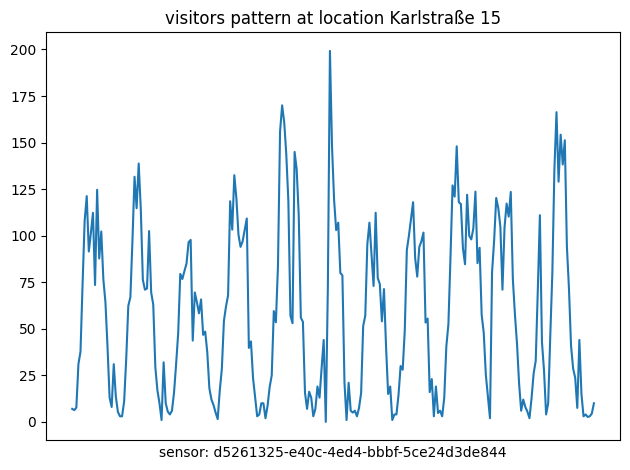

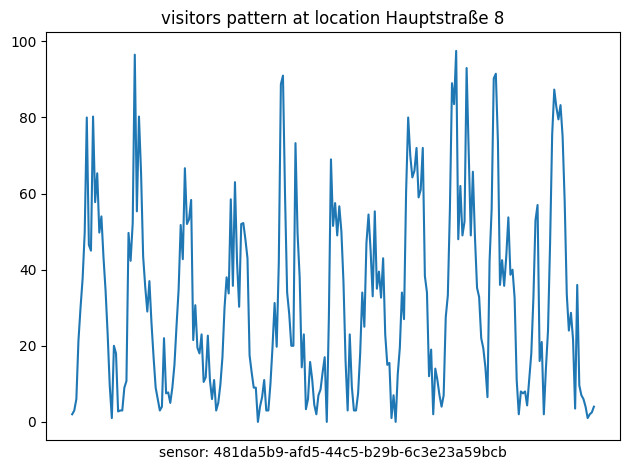

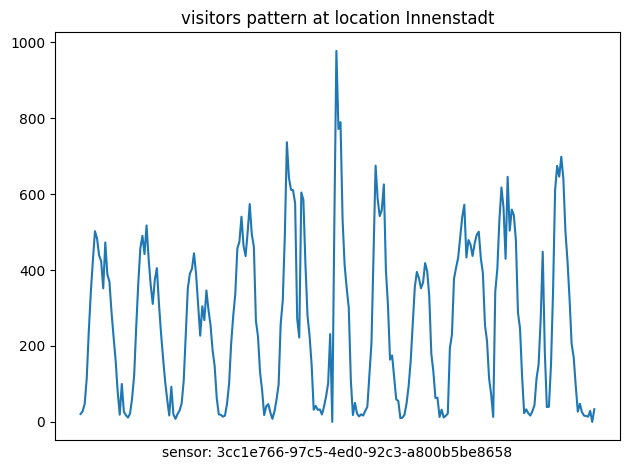

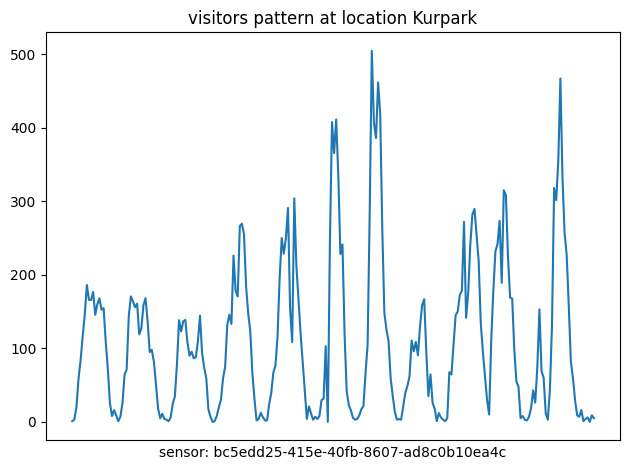

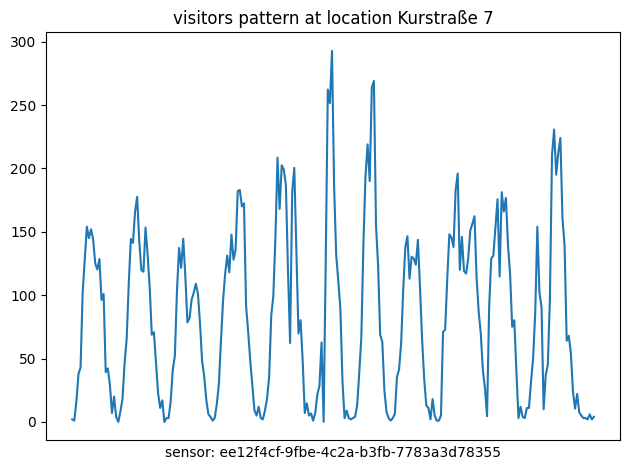

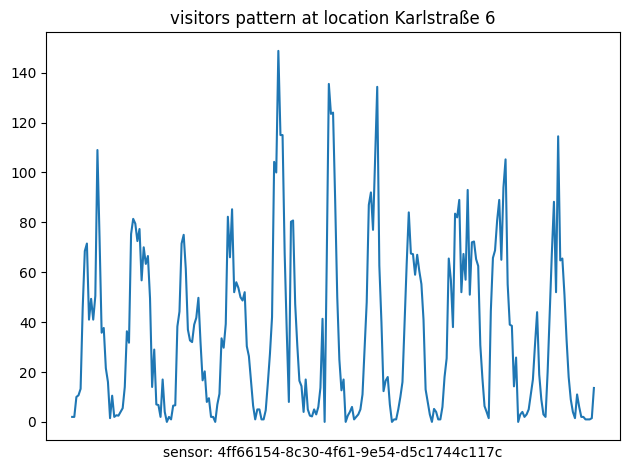

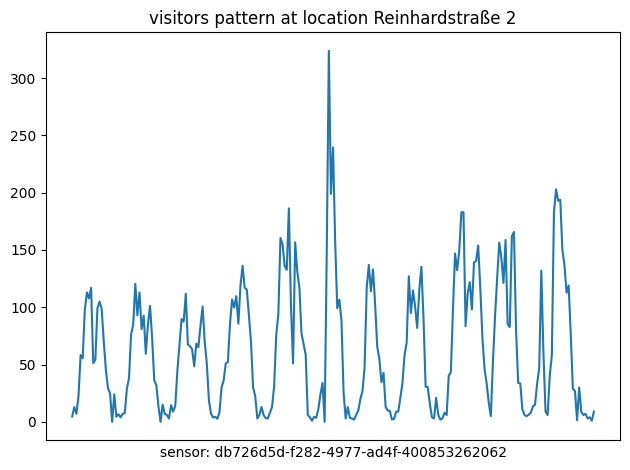

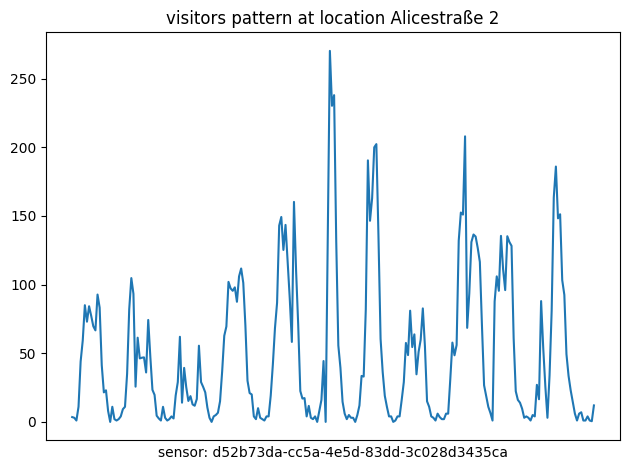

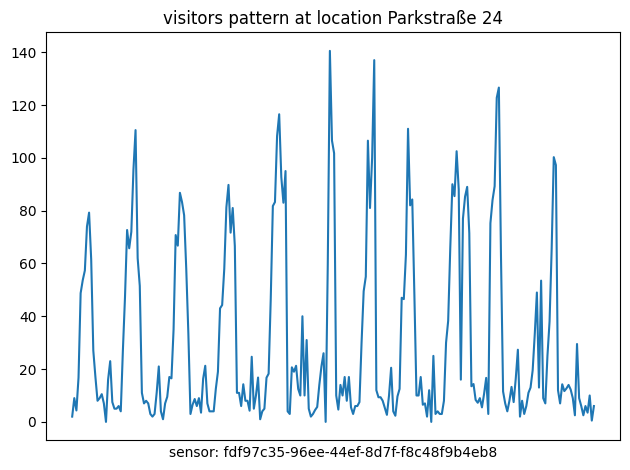

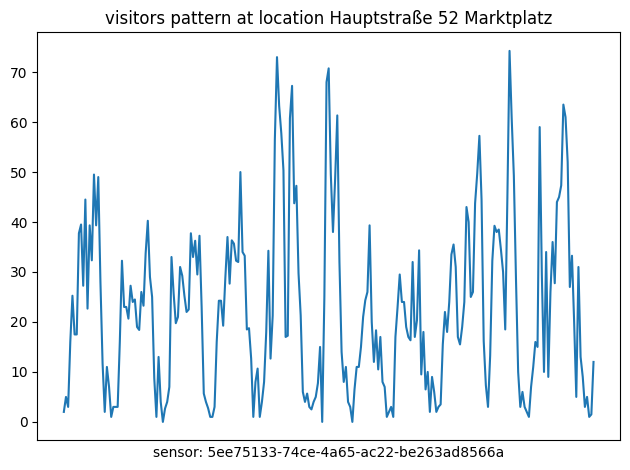

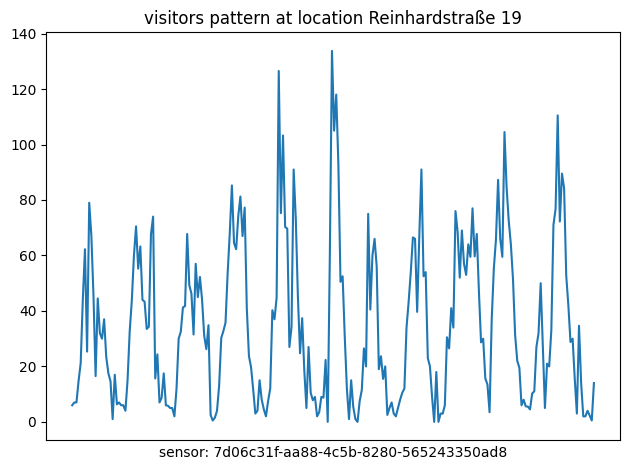

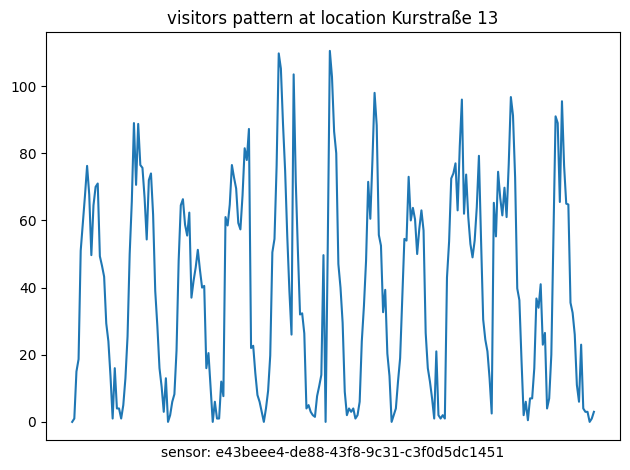

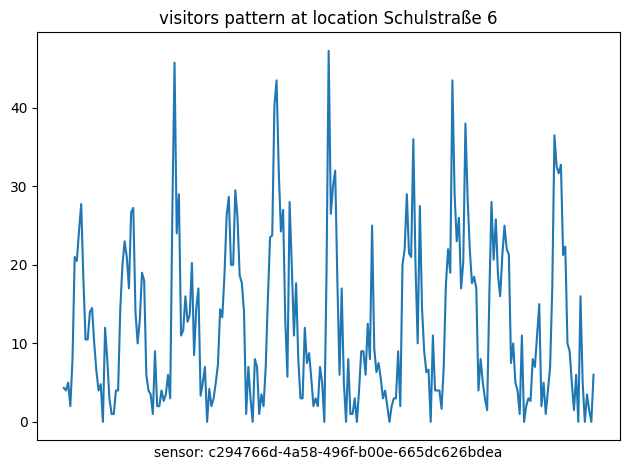

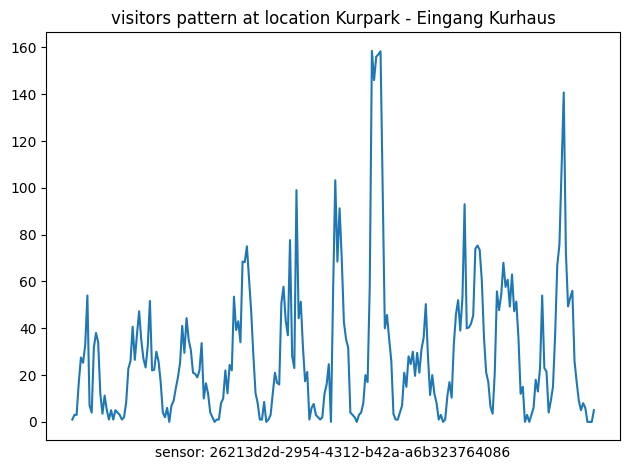

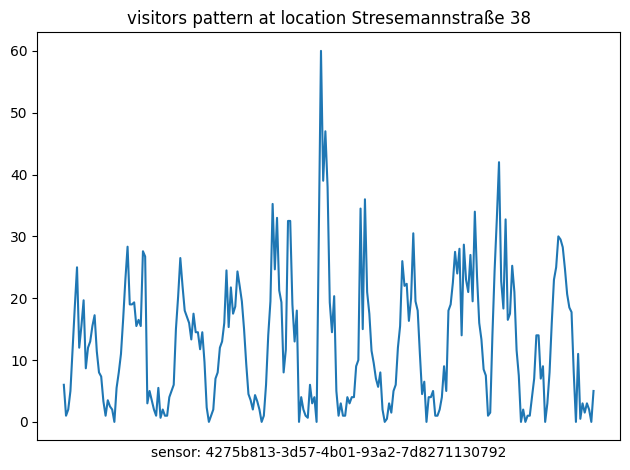

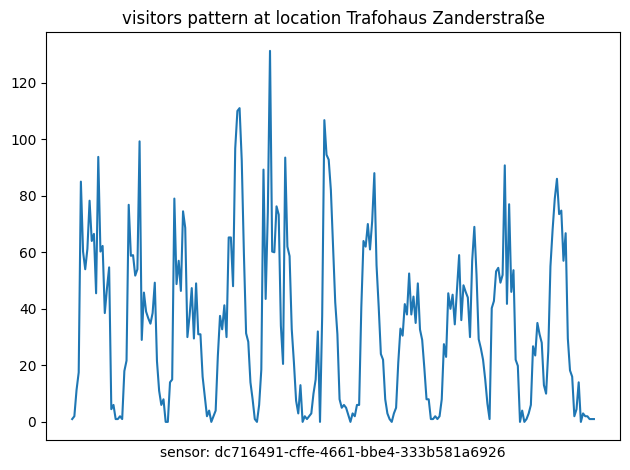

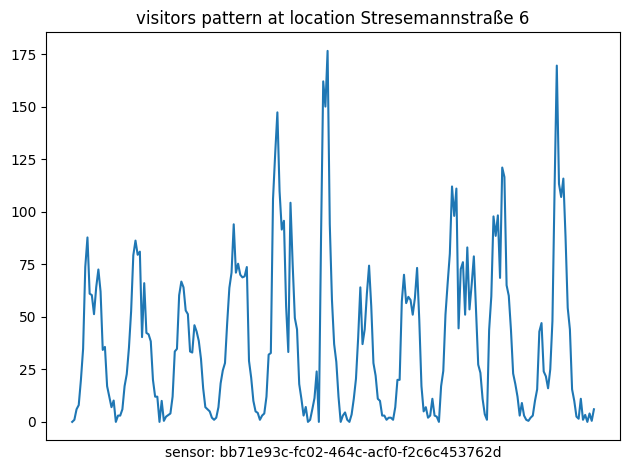

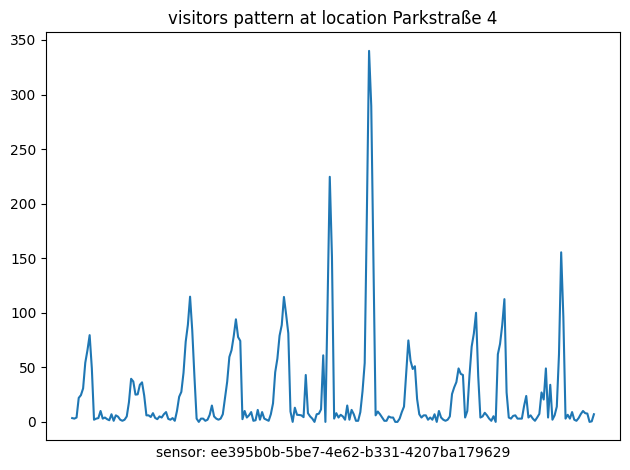

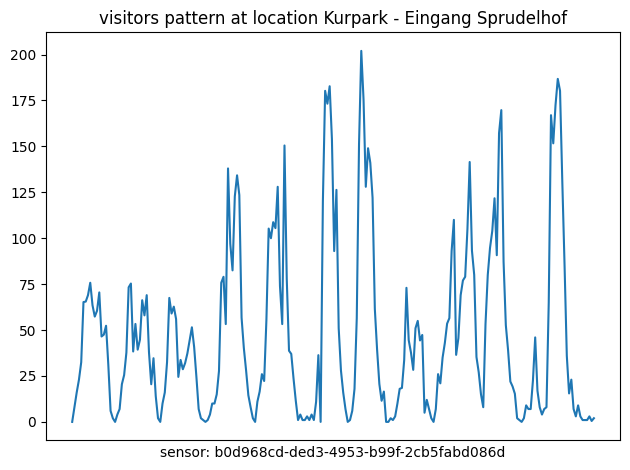

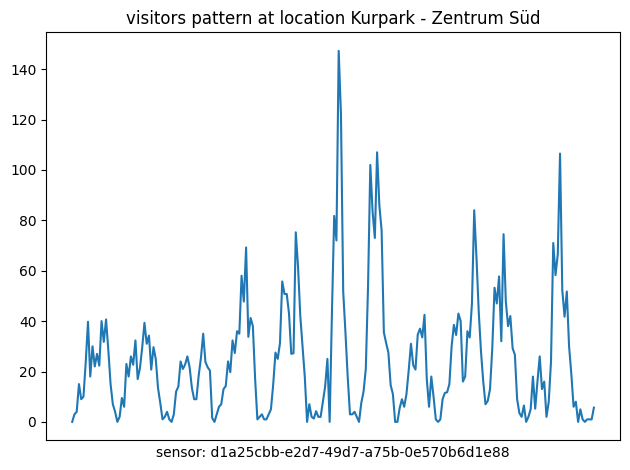

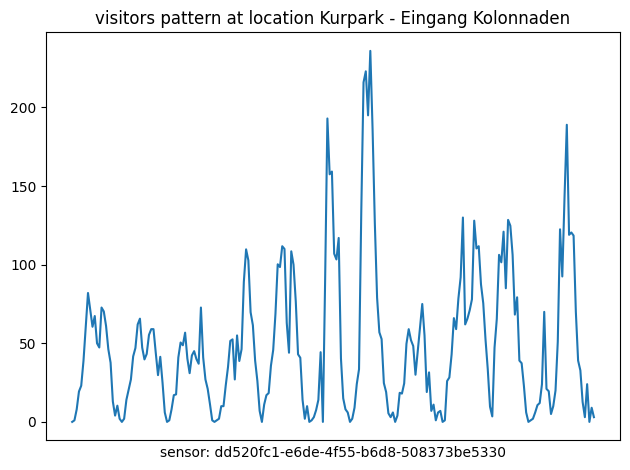

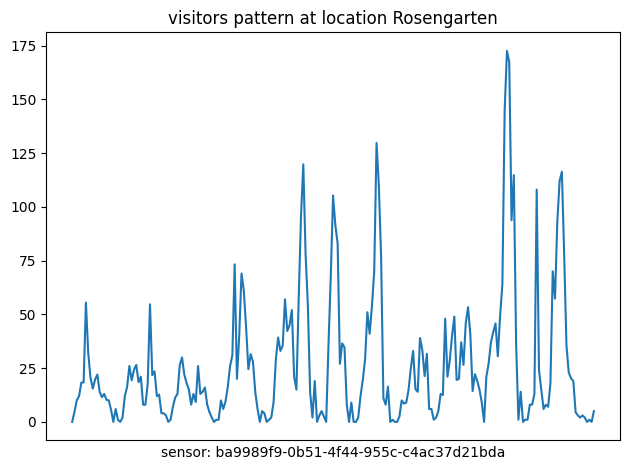

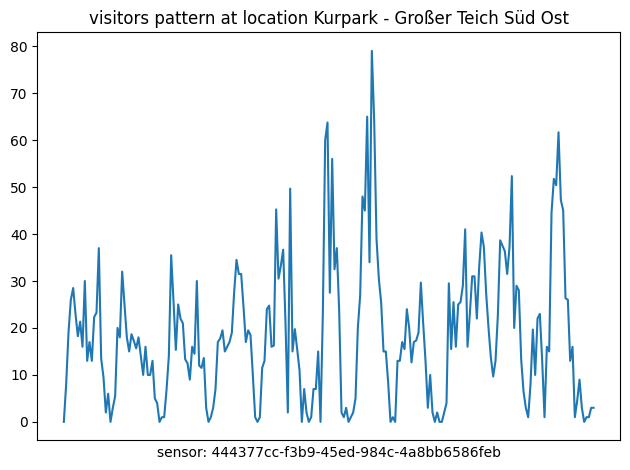

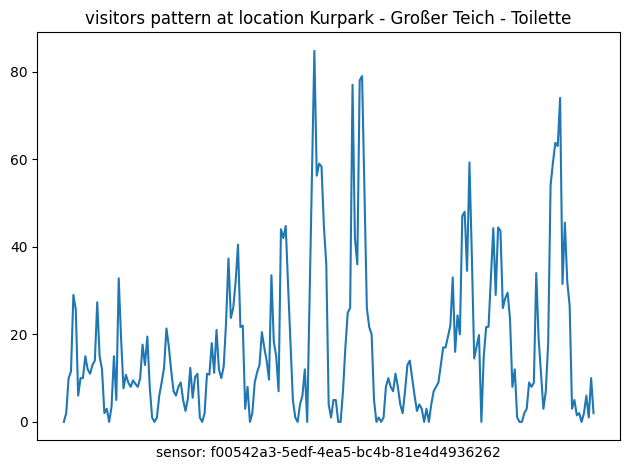

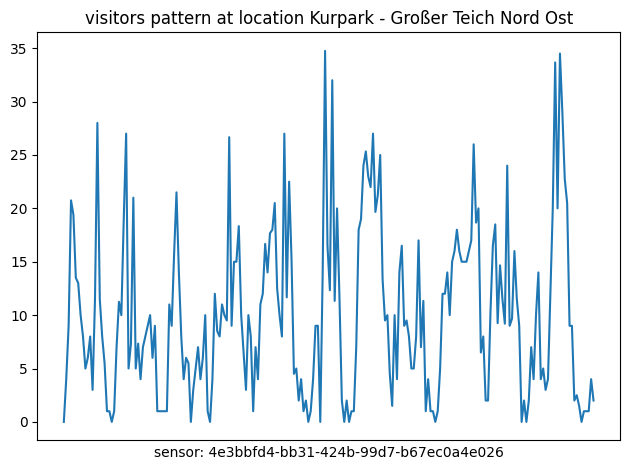

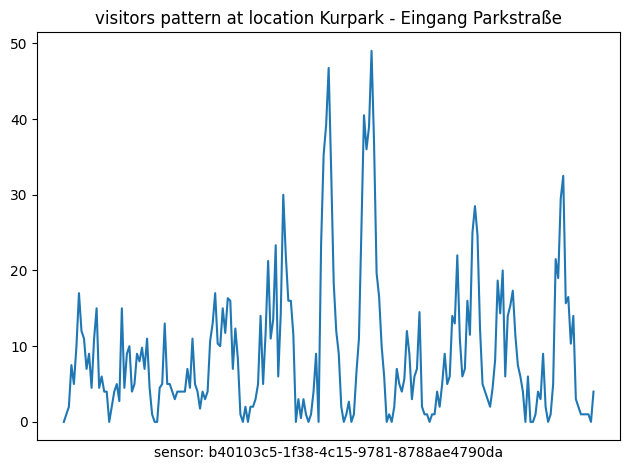

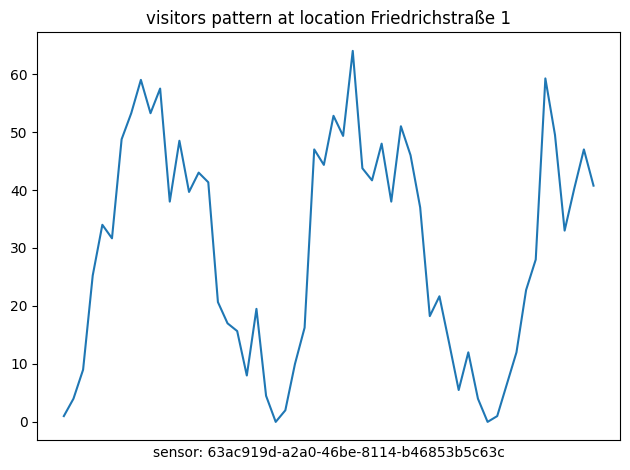

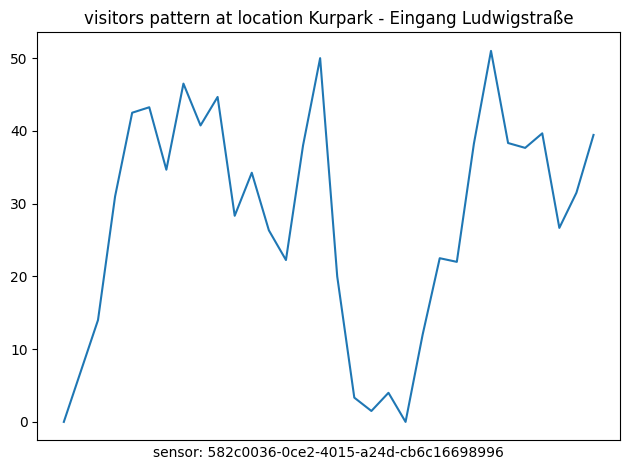

In [32]:
for sensor in sensors:
    pattern_analysis(sensor)

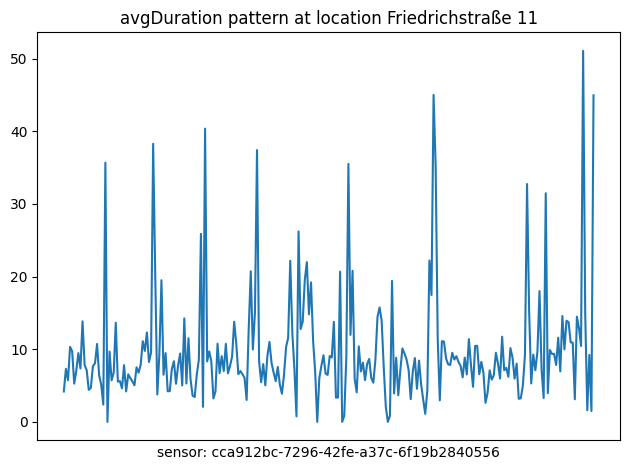

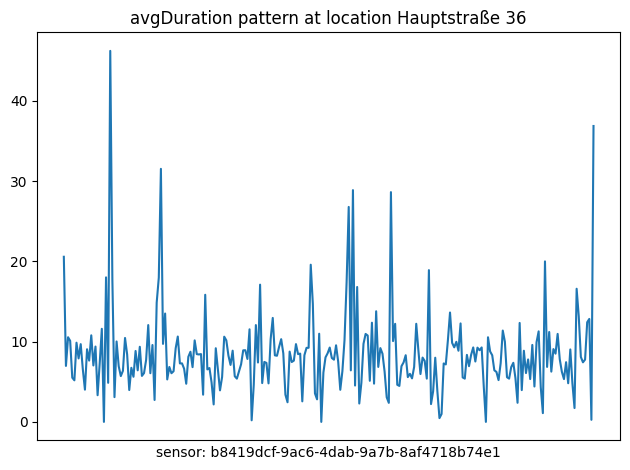

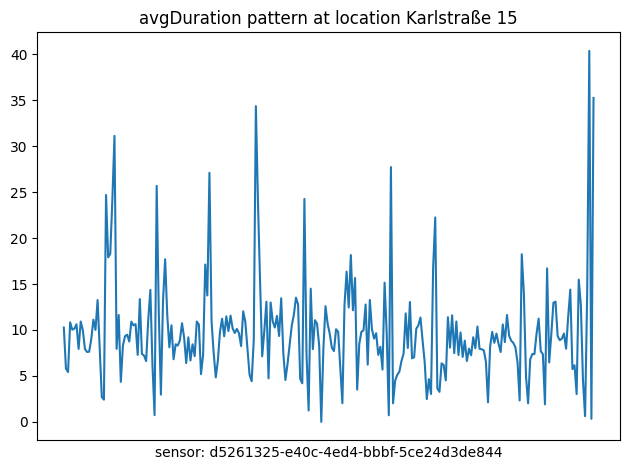

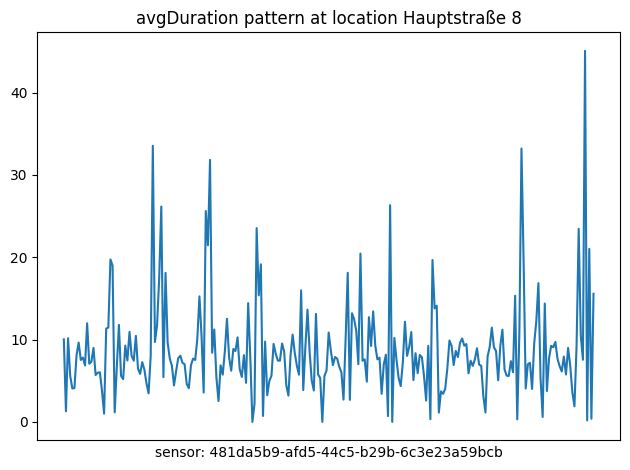

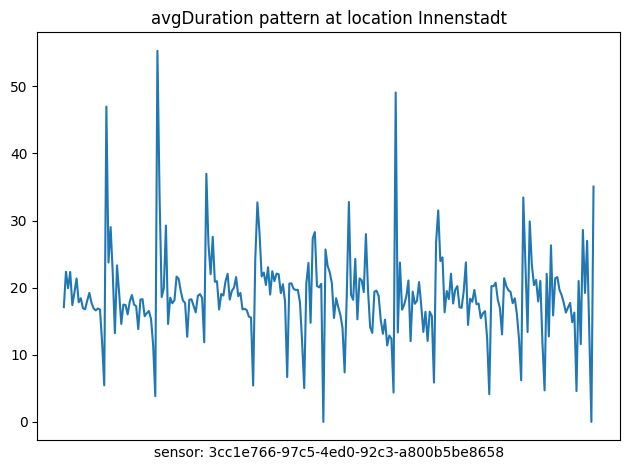

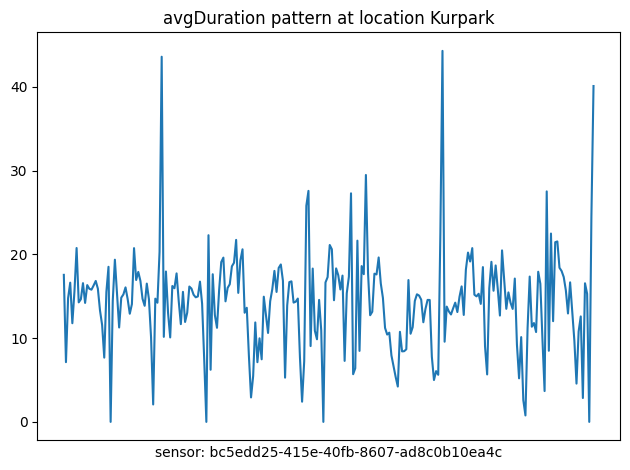

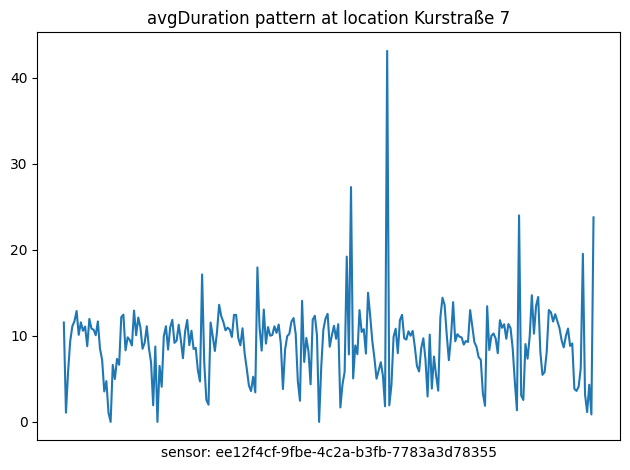

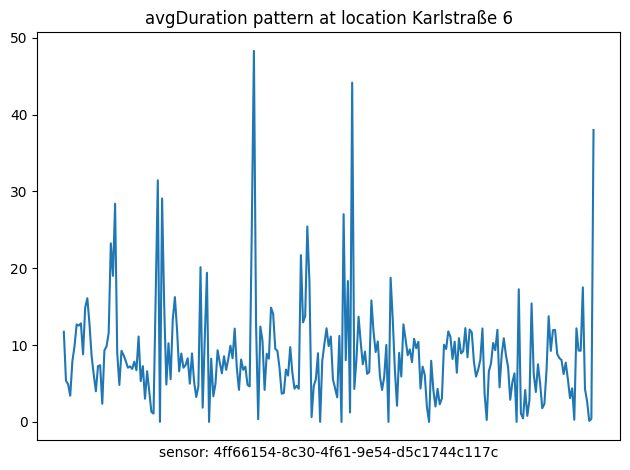

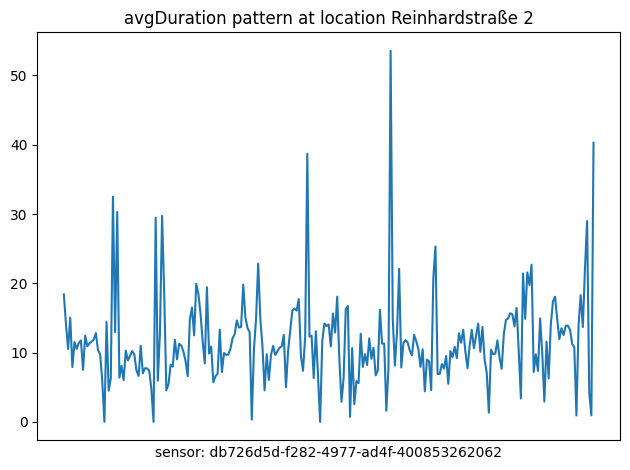

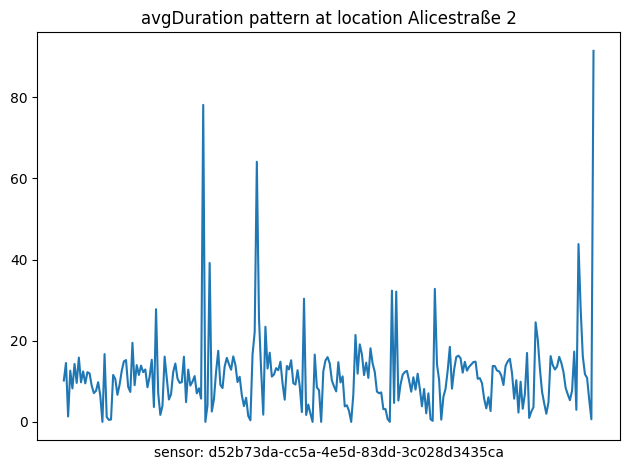

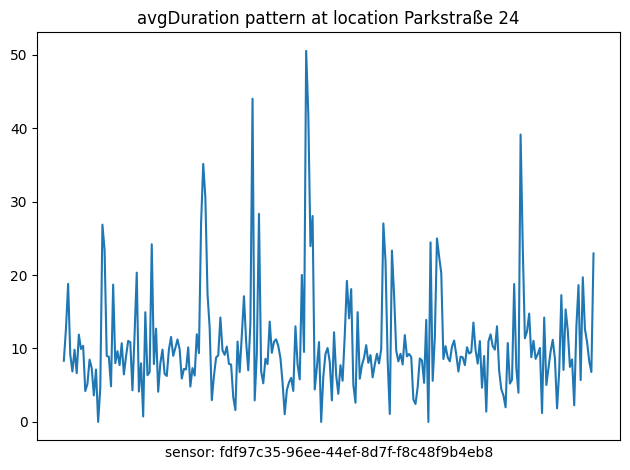

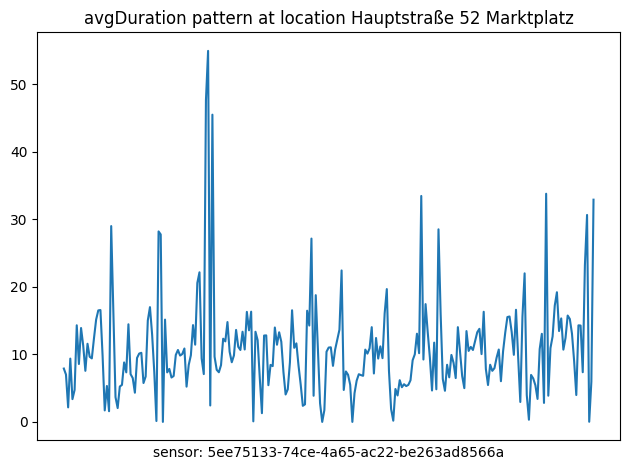

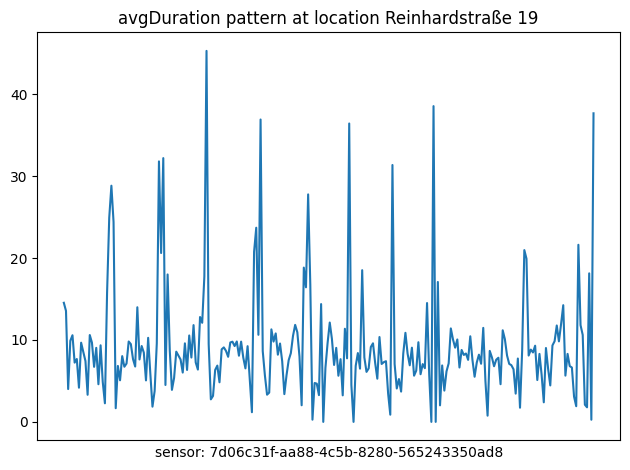

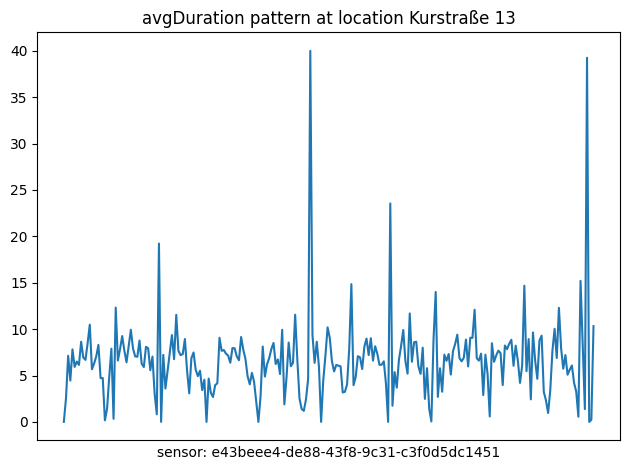

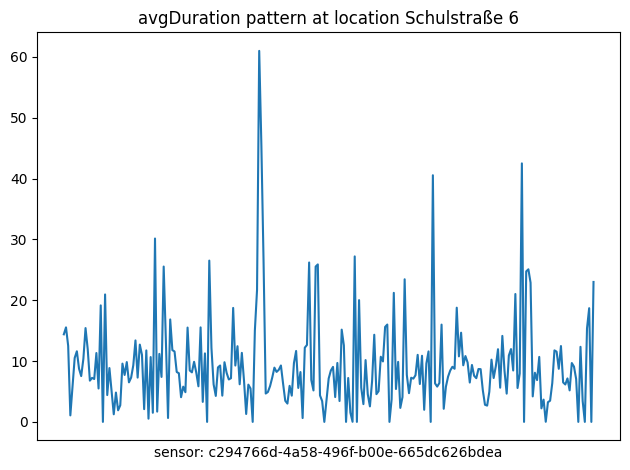

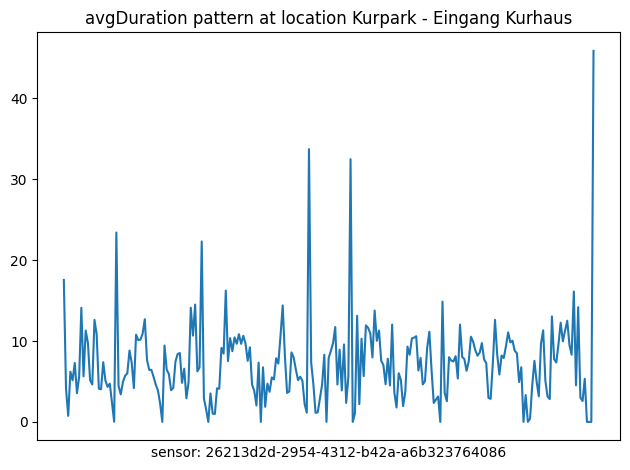

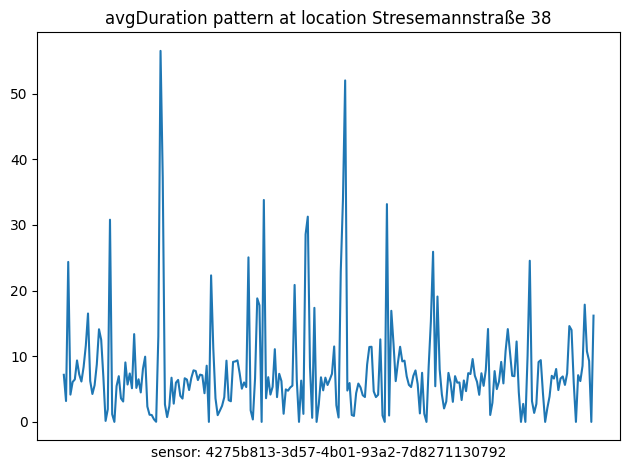

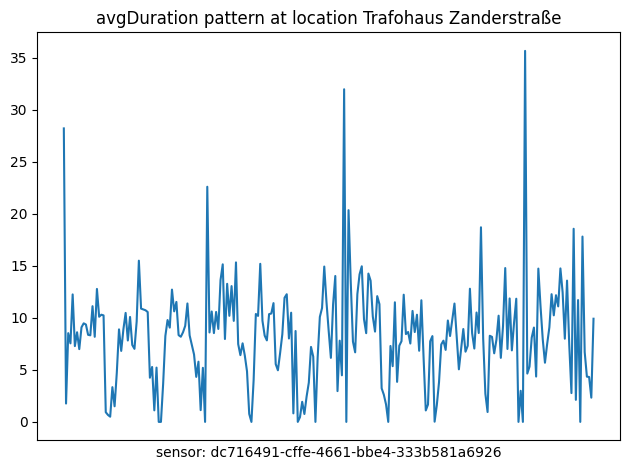

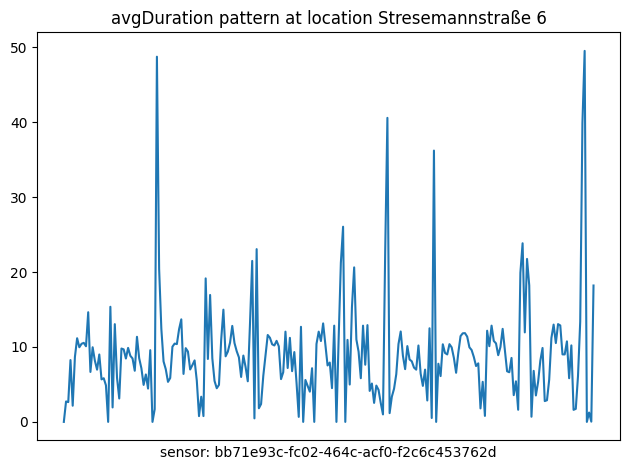

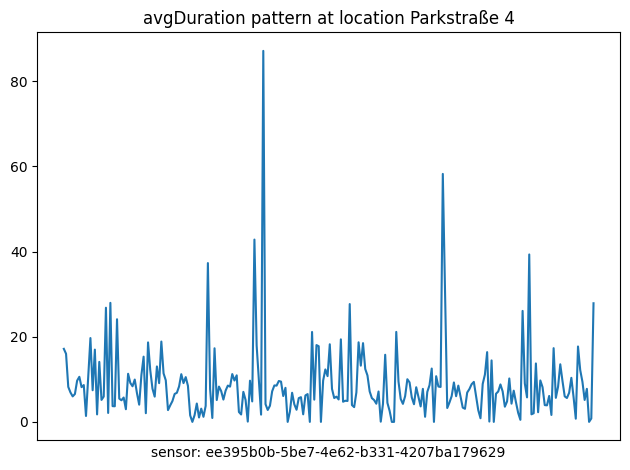

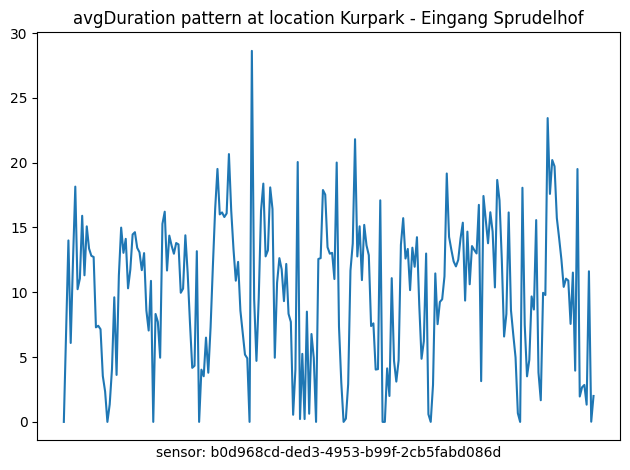

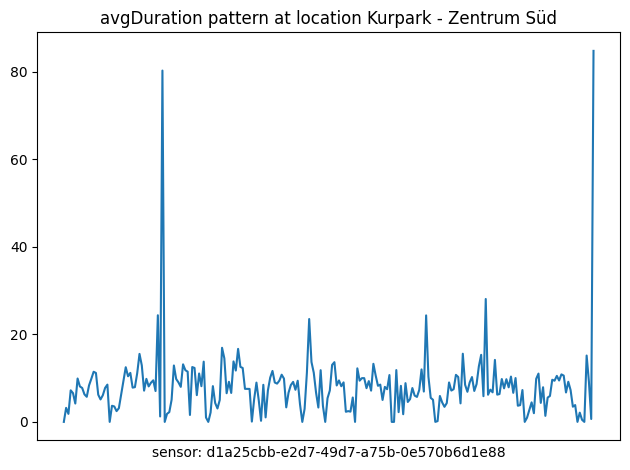

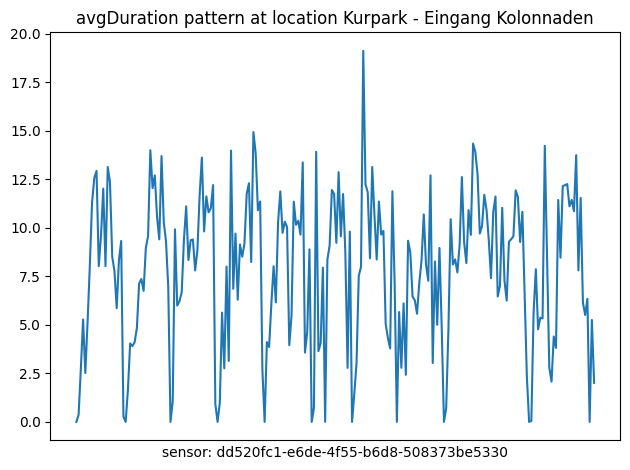

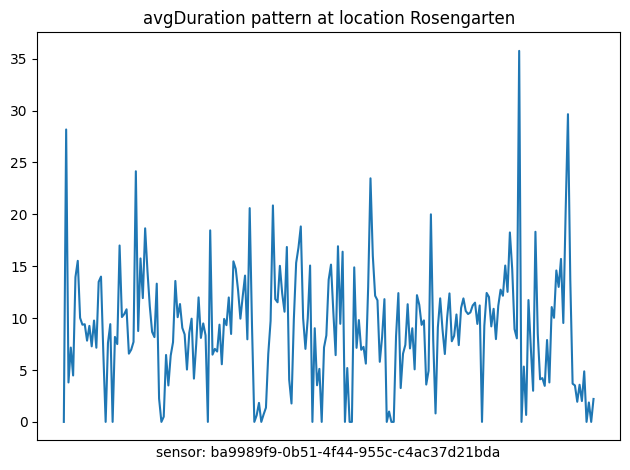

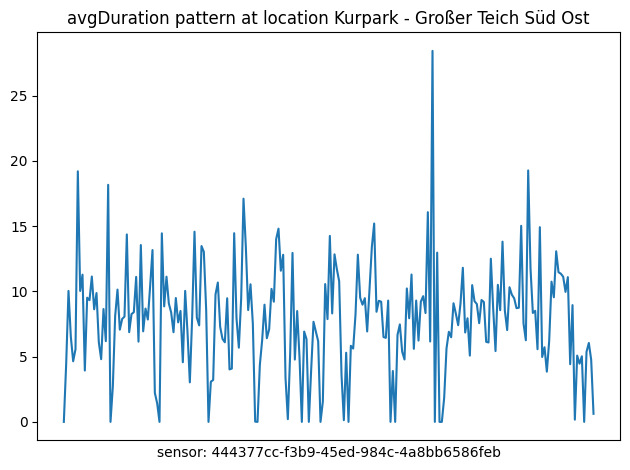

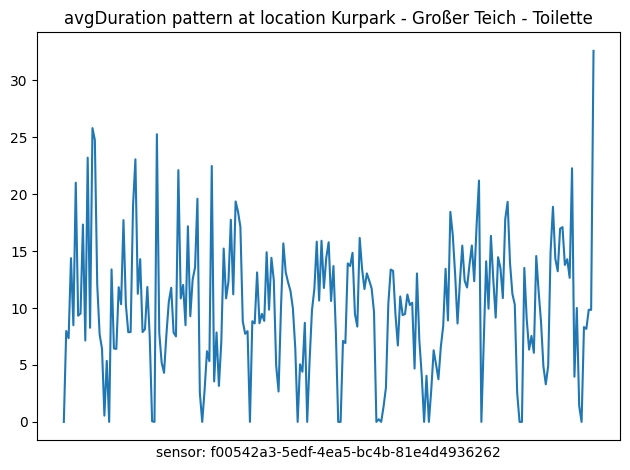

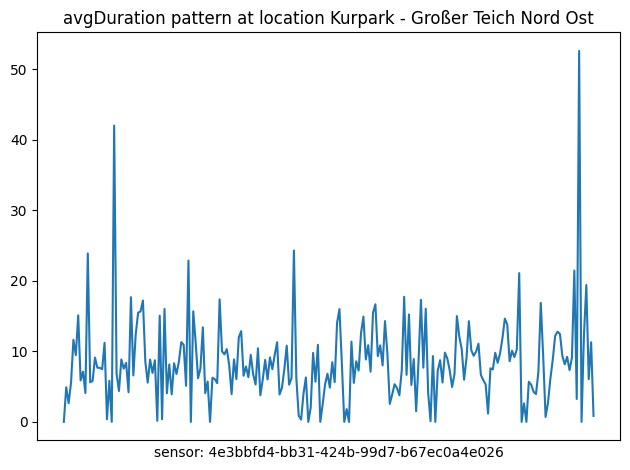

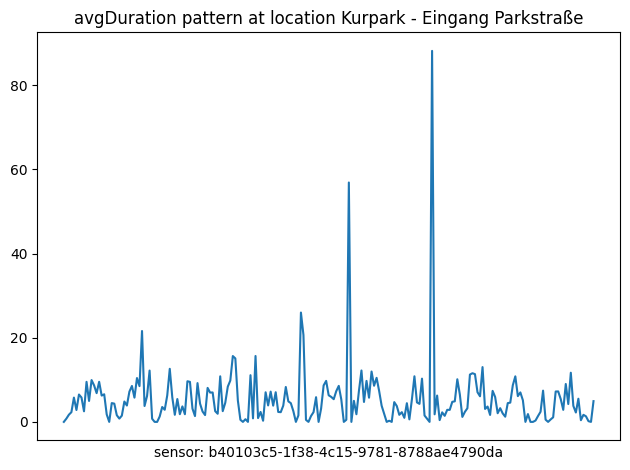

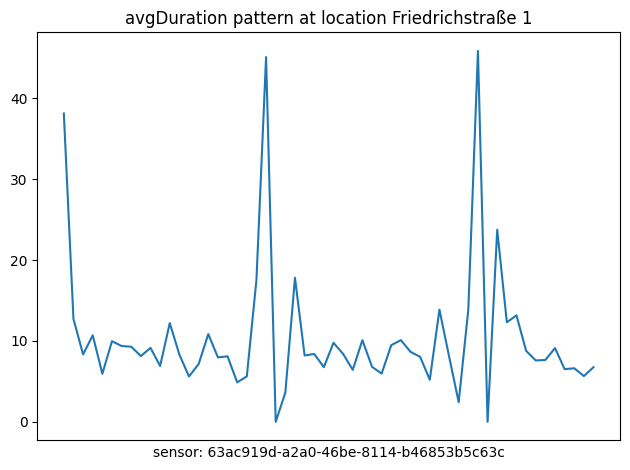

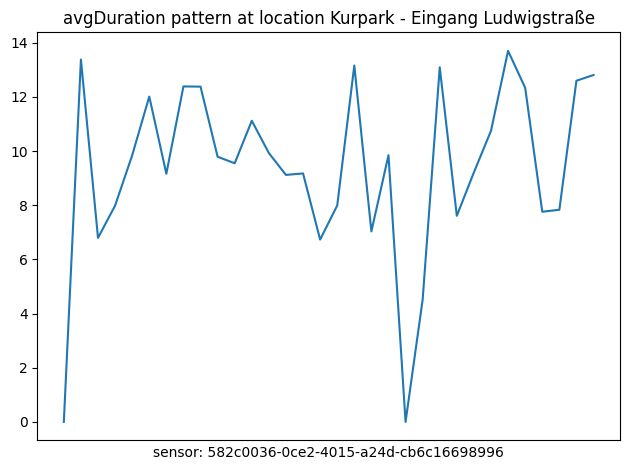

In [33]:
for sensor in sensors:
    avgDuration_pattern_analysis(sensor)

In [35]:
df.to_csv("final_data.csv")